# Exam Hand-In - Data and Things
**Jonas Wolffrom Strandgaard Clausen - jwsc@ruc.dk**

## Imports and Setup

In [127]:
%matplotlib inline

# Standard and math imports
import os
import threading
import time
import numpy as np
import pandas as pd

# Plotting libs
import matplotlib.pyplot as plt
import seaborn as sns

# Data Science libs
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Machine Learning libs
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage
import statsmodels.api as sm
import shap
import lime
from lime import lime_tabular
import networkx as nx
import paho.mqtt.client as mqtt

# XGBoost
from xgboost import XGBRegressor

# Sklearn imports
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, f1_score, silhouette_score,
    mean_squared_error, mean_absolute_error, adjusted_rand_score
)
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import partial_dependence, PartialDependenceDisplay
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler, StandardScaler


---
# 1. Data Transformation and Exploratory Data Analysis (EDA)

**Exercise:** Do an exploratory data analysis of the adult dataset.

**Requirements:**
- Explain what the data is about and which variables the dataset contains
- Explain data types of each variable
- Investigate distribution/variation through visualization and descriptive statistics for each individual variable
- Investigate variation/correlation between pairs of variables:
  - One case where both variables are categorical
  - One case where both variables are numeric
  - One case where one is categorical and one is numeric

## Load and Explore Adult Dataset

In [128]:
adults = pd.read_csv("Data/adult.csv")
adults.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## Dataset Overview and Variable Types

In [129]:
# Dataset information
print("Dataset Shape:", adults.shape)
print("\nColumn Data Types:")
print(adults.dtypes)
print("\nDataset Info:")
adults.info()
print("\nDescriptive Statistics:")
adults.describe()

Dataset Shape: (48842, 15)

Column Data Types:
age               int64
workclass           str
fnlwgt            int64
education           str
education-num     int64
marital-status      str
occupation          str
relationship        str
race                str
sex                 str
capital-gain      int64
capital-loss      int64
hours-per-week    int64
native-country      str
income              str
dtype: object

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             48842 non-null  int64
 1   workclass       47879 non-null  str  
 2   fnlwgt          48842 non-null  int64
 3   education       48842 non-null  str  
 4   education-num   48842 non-null  int64
 5   marital-status  48842 non-null  str  
 6   occupation      47876 non-null  str  
 7   relationship    48842 non-null  str  
 8   race            48842 non-null 

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


## Individual Variable Analysis

### Age Analysis

In [130]:
# Mean age analysis
mean_age = adults["age"].mean()
male_age = adults[adults["sex"] == "Male"]["age"]
mean_male_age = male_age.mean()
female_age = adults[adults["sex"] == "Female"]["age"]
mean_female_age = female_age.mean()

print(f"Overall mean age: {mean_age:.2f}")
print(f"Mean male age: {mean_male_age:.2f}")
print(f"Mean female age: {mean_female_age:.2f}")
print(f"Age difference (Male - Female): {mean_male_age - mean_female_age:.2f}")

Overall mean age: 38.64
Mean male age: 39.49
Mean female age: 36.93
Age difference (Male - Female): 2.57


### Education Analysis

Education Distribution:
       education  people_count
0        HS-grad         15784
1   Some-college         10878
2      Bachelors          8025
3        Masters          2657
4      Assoc-voc          2061
5           11th          1812
6     Assoc-acdm          1601
7           10th          1389
8        7th-8th           955
9    Prof-school           834
10           9th           756
11          12th           657
12     Doctorate           594
13       5th-6th           509
14       1st-4th           247
15     Preschool            83


<Figure size 1200x600 with 0 Axes>

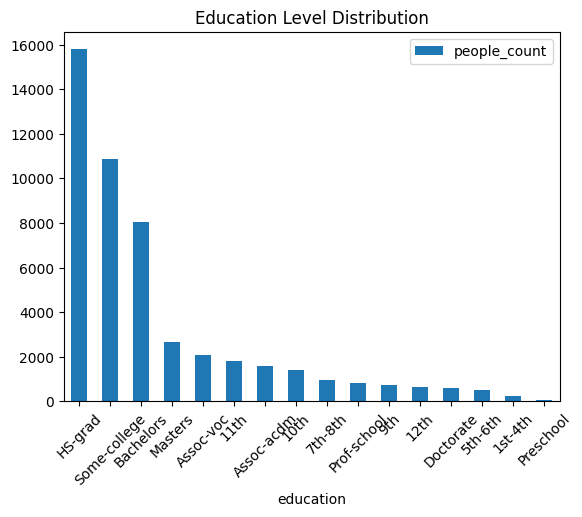

In [131]:
# Education types and counts
educations = adults["education"].value_counts().reset_index()
educations.columns = ["education", "people_count"]
print("Education Distribution:")
print(educations)

# Visualize education distribution
plt.figure(figsize=(12, 6))
educations.plot(x="education", y="people_count", kind="bar", title="Education Level Distribution")
plt.xticks(rotation=45)
plt.show()

## Pairwise Variable Analysis

### Case 1: Both Categorical - Sex vs Education Level

In [132]:
# Education level comparison by sex
male_education_levels = adults[adults["sex"] == "Male"]["education-num"]
mean_male_education_level = male_education_levels.mean()

female_education_levels = adults[adults["sex"] == "Female"]["education-num"]
mean_female_education_level = female_education_levels.mean()

print(f"Mean education level (Male): {mean_male_education_level:.2f}")
print(f"Mean education level (Female): {mean_female_education_level:.2f}")
print(f"Difference: {mean_male_education_level - mean_female_education_level:.2f}")

Mean education level (Male): 10.09
Mean education level (Female): 10.04
Difference: 0.05


### Case 2: Both Numeric - Age vs Hours Worked

Correlation between age and hours per week: 0.0716


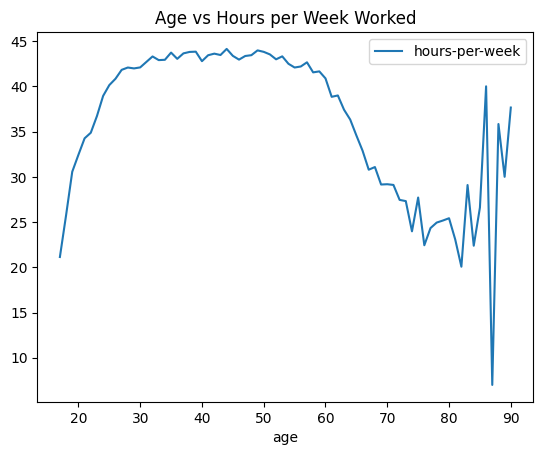

In [133]:
# Correlation between age and hours worked
age_vs_work_hours = pd.DataFrame()
age_vs_work_hours["age"] = adults["age"]
age_vs_work_hours["hours-per-week"] = adults["hours-per-week"]

correlation = age_vs_work_hours["age"].corr(age_vs_work_hours["hours-per-week"])
print(f"Correlation between age and hours per week: {correlation:.4f}")

# Visualize
grouped_age_vs_work_hours = age_vs_work_hours.groupby("age").mean().reset_index()
grouped_age_vs_work_hours.plot(x="age", y="hours-per-week", kind="line", 
                                title="Age vs Hours per Week Worked")
plt.show()

### Case 3: Categorical vs Numeric - Sex vs Income

Income distribution by sex:
income     sex  <=50K  <=50K.  >50K  >50K.
0       Female   9592    4831  1179    590
1         Male  15128    7604  6662   3256


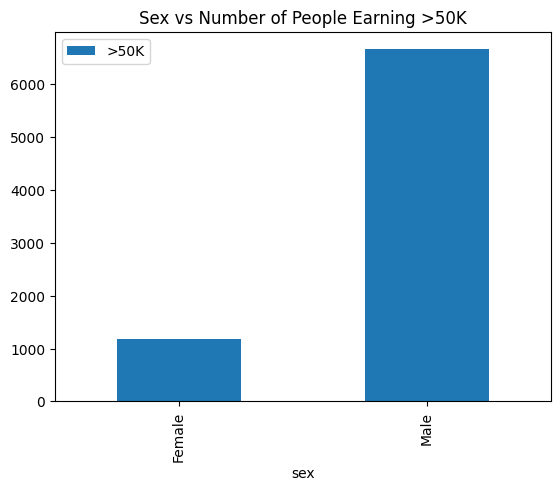

In [134]:
# Income comparison by sex
income_by_sex = pd.DataFrame()
income_by_sex["sex"] = adults["sex"]
income_by_sex["income"] = adults["income"]

grouped_income_by_sex = income_by_sex.groupby("sex").value_counts().unstack().reset_index()
print("Income distribution by sex:")
print(grouped_income_by_sex)

# Visualize
grouped_income_by_sex.plot(x="sex", y=">50K", kind="bar", 
                           title="Sex vs Number of People Earning >50K")
plt.show()

---
# 2. Statistics

**Exercise 3.1:** Using the penguins dataset, answer the following:
1. For different species of penguins, how many penguins are there of each species?
2. Is the body mass variable normally distributed for each species?
3. Test whether there is a difference in body mass for Adelie and Chinstrap penguins
4. Test whether there is a difference in body mass for Chinstrap and Gentoo penguins

**Exercise 3.2:** Load the "fb_like_and_share.csv" data and answer:
1. Is there a difference in distribution of likes for photos and videos?
2. Is there a difference in distribution of share counts for photos and videos?
3. Perform an ANOVA test for shares across post types
4. Is there a statistical significant difference in share counts for any two groups?

## Exercise 3.1: Penguins Analysis

In [135]:
# Load penguins dataset
penguins_data = sns.load_dataset("penguins")
penguins_data.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


### 1. Count of penguins per species

     species  count
0     Adelie    152
1     Gentoo    124
2  Chinstrap     68


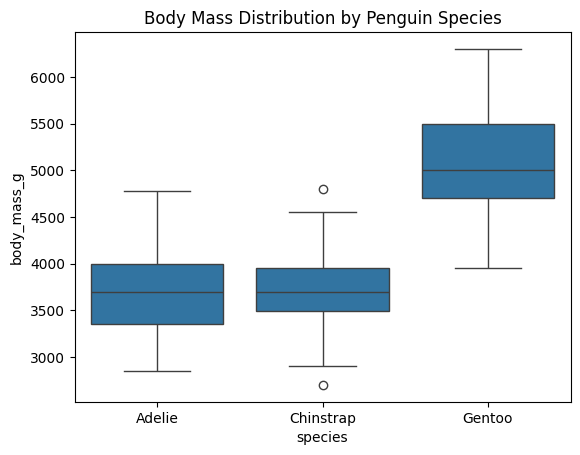

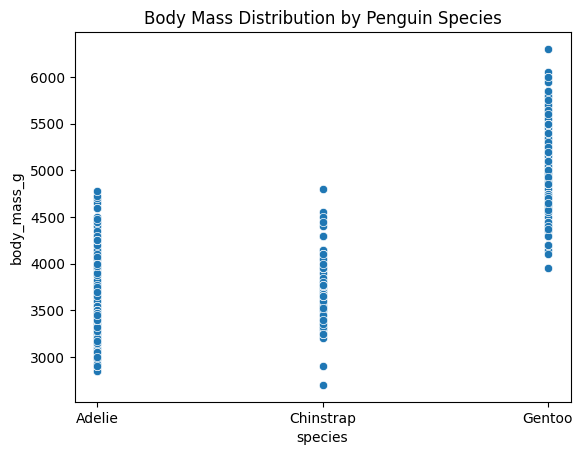

In [136]:
amount_penguins_per_species = penguins_data["species"].value_counts().reset_index()
amount_penguins_per_species.columns = ["species", "count"]
print(amount_penguins_per_species)

# Visualize
sns.boxplot(x="species", y="body_mass_g", data=penguins_data)
plt.title("Body Mass Distribution by Penguin Species")
plt.show()

sns.scatterplot(x="species", y="body_mass_g", data=penguins_data)
plt.title("Body Mass Distribution by Penguin Species")
plt.show()

### 2. Test for normal distribution

In [137]:
adelie_penguins = penguins_data[penguins_data["species"] == "Adelie"]
chinstrap_penguins = penguins_data[penguins_data["species"] == "Chinstrap"]
gentoo_penguins = penguins_data[penguins_data["species"] == "Gentoo"]

# Shapiro-Wilk test for Adelie
statistic, p_value = stats.shapiro(adelie_penguins["body_mass_g"].dropna())
print("Shapiro-Wilk Test for Adelie Penguins Body Mass:")
print("T-statistic:", statistic)
print("P-value:", p_value)

# Shapiro-Wilk test for Chinstrap
statistic, p_value = stats.shapiro(chinstrap_penguins["body_mass_g"].dropna())
print("\nShapiro-Wilk Test for Chinstrap Penguins Body Mass:")
print("T-statistic:", statistic)
print("P-value:", p_value)

# Shapiro-Wilk test for Gentoo
statistic, p_value = stats.shapiro(gentoo_penguins["body_mass_g"].dropna())
print("\nShapiro-Wilk Test for Gentoo Penguins Body Mass:")
print("T-statistic:", statistic)
print("P-value:", p_value)

Shapiro-Wilk Test for Adelie Penguins Body Mass:
T-statistic: 0.9807078507062791
P-value: 0.03239702501305105

Shapiro-Wilk Test for Chinstrap Penguins Body Mass:
T-statistic: 0.984493761674102
P-value: 0.5605082387697975

Shapiro-Wilk Test for Gentoo Penguins Body Mass:
T-statistic: 0.9859276066609362
P-value: 0.23361648888961845


### 3. Test difference between Adelie and Chinstrap

We see that Chinstrap penguins are likely normally distributed, but Adelie are not. Thus we use a Mann-Whitney U test.

**H₀:** There is no difference in body mass between Adelie and Chinstrap penguins (μ_Adelie = μ_Chinstrap)

**H₁:** There is a difference in body mass between Adelie and Chinstrap penguins (μ_Adelie ≠ μ_Chinstrap)

**α = 0.05**

In [138]:
u_statistic, p_value_u = stats.mannwhitneyu(adelie_penguins["body_mass_g"].dropna(), 
                                            chinstrap_penguins["body_mass_g"].dropna())
print("Mann-Whitney U Test between Adelie and Chinstrap Penguins Body Mass:")
print("U-statistic:", u_statistic)
print("P-value:", p_value_u)
print("\nConclusion: From the result we see that there is no difference in body mass between the two penguin species.")

Mann-Whitney U Test between Adelie and Chinstrap Penguins Body Mass:
U-statistic: 4831.0
P-value: 0.4854772721011861

Conclusion: From the result we see that there is no difference in body mass between the two penguin species.


### 4. Test difference between Chinstrap and Gentoo

With a p-value well above 0.05, Gentoo penguins are likely normally distributed, so we use a t-test.

**H₀:** There is no difference in body mass between Gentoo and Chinstrap penguins (μ_Gentoo = μ_Chinstrap)

**H₁:** There is a difference in body mass between Gentoo and Chinstrap penguins (μ_Gentoo ≠ μ_Chinstrap)

**α = 0.05**

In [139]:
statistic, p_value = stats.ttest_ind(gentoo_penguins["body_mass_g"].dropna(), 
                                     chinstrap_penguins["body_mass_g"].dropna())
print("T-Test between Gentoo and Chinstrap Penguins Body Mass:")
print("T-statistic:", statistic)
print("P-value:", round(p_value, 50))
print("\nConclusion: Seeing as the p-value is very well below 0.05, it strongly suggests that there is a difference in body mass between Gentoo and Chinstrap penguins, thus rejecting the null hypothesis.")

T-Test between Gentoo and Chinstrap Penguins Body Mass:
T-statistic: 19.103227243520955
P-value: 5.2661999999999995e-46

Conclusion: Seeing as the p-value is very well below 0.05, it strongly suggests that there is a difference in body mass between Gentoo and Chinstrap penguins, thus rejecting the null hypothesis.


## Exercise 3.2: Facebook Likes and Shares Analysis

In [140]:
fb_like_and_share = pd.read_csv("Data/fb_like_and_share.csv", sep=";")
fb_like_and_share.head()

,type,likes_count_fb,shares_count_fb
0,video,577,7
1,photo,2802,23
2,video,490,14
3,link,535,16
4,photo,1049,44


In [141]:
fb_photos = fb_like_and_share[fb_like_and_share["type"] == "photo"]
fb_videos = fb_like_and_share[fb_like_and_share["type"] == "video"]

print("Facebook Photos Data:")
print(fb_photos)
print("\nFacebook Videos Data:")
print(fb_videos)

Facebook Photos Data:
     type  likes_count_fb  shares_count_fb
1   photo            2802               23
4   photo            1049               44
5   photo            1557               85
6   photo             838                1
8   photo             100                1
10  photo            1258               19
11  photo             487                5
12  photo             184               12
14  photo             653               43
19  photo             637                3
26  photo            1544               47
27  photo             320                0
28  photo             329                3

Facebook Videos Data:
     type  likes_count_fb  shares_count_fb
0   video             577                7
2   video             490               14
9   video             112                3
13  video            1051               78
17  video              35                0
20  video             116                1
22  video             175                0
30  video

### 1. Test for difference in likes distribution

We begin by assuming both sets are normally distributed, with an α = 0.05

In [142]:
# Test for normality
statistic, p_value = stats.shapiro(fb_photos["likes_count_fb"].dropna())
print("Shapiro-Wilk Test for Facebook Photos Like Count:")
print("T-statistic:", statistic)
print("P-value:", p_value)

statistic, p_value = stats.shapiro(fb_videos["likes_count_fb"].dropna())
print("\nShapiro-Wilk Test for Facebook Videos Like Count:")
print("T-statistic:", statistic)
print("P-value:", p_value)

Shapiro-Wilk Test for Facebook Photos Like Count:
T-statistic: 0.8774655646725982
P-value: 0.06589939260226885

Shapiro-Wilk Test for Facebook Videos Like Count:
T-statistic: 0.8477493538641958
P-value: 0.07038250110283344


Seeing values above 0.05 for both data sets, we can see that the data is normally distributed. We can use a t-test:

**H₀:** There is no difference between like counts (μ_Photos = μ_Videos)

**H₁:** There is a difference between like counts (μ_Photos ≠ μ_Videos)

**α = 0.05**

In [143]:
statistics, p_value = stats.ttest_ind(fb_photos["likes_count_fb"].dropna(), 
                                      fb_videos["likes_count_fb"].dropna())

print("T-Test between Facebook Photos and Videos Like Count:")
print("T-statistic:", statistics)
print("P-value:", p_value)
print("\nConclusion: Looking at the p-value of 0.046, which is below the significance level, we reject the null hypothesis as there's a somewhat strong indication of a difference in like counts between the two sets.")

T-Test between Facebook Photos and Videos Like Count:
T-statistic: 2.125454058083514
P-value: 0.04619850270741723

Conclusion: Looking at the p-value of 0.046, which is below the significance level, we reject the null hypothesis as there's a somewhat strong indication of a difference in like counts between the two sets.


### 2-4. Share Count Analysis, ANOVA, and Pairwise Comparisons (Q2-Q4)


In [144]:

# Q2: Difference in share counts for photos vs videos
print("=== Q2: Share Count Distribution (Photos vs Videos) ===")
stat, p = stats.shapiro(fb_photos["shares_count_fb"].dropna())
print(f"Shapiro-Wilk for Photo shares:  stat={stat:.4f}, p={p:.4f}")
stat, p = stats.shapiro(fb_videos["shares_count_fb"].dropna())
print(f"Shapiro-Wilk for Video shares:  stat={stat:.4f}, p={p:.4f}")
print("→ Share counts are skewed; use Mann-Whitney U as non-parametric test.")

# H₀: no difference in share count distribution between photos and videos
# H₁: there is a difference  (α = 0.05)
u_stat, p_mw = stats.mannwhitneyu(
    fb_photos["shares_count_fb"].dropna(),
    fb_videos["shares_count_fb"].dropna(),
    alternative="two-sided"
)
print(f"\nMann-Whitney U (Photos vs Videos — shares): U={u_stat:.2f}, p={p_mw:.4f}")
if p_mw < 0.05:
    print("  → p < 0.05: Reject H₀ — significant difference in share counts between photos and videos.")
else:
    print("  → p ≥ 0.05: Fail to reject H₀ — no significant difference in share counts.")

# Q3: ANOVA for shares across all post types
print("\n=== Q3: ANOVA for Shares Across Post Types ===")
groups_shares = [
    grp["shares_count_fb"].dropna()
    for _, grp in fb_like_and_share.groupby("type")
]
f_stat, p_anova = stats.f_oneway(*groups_shares)
print(f"ANOVA: F={f_stat:.4f}, p={p_anova:.4f}")
print("Note: ANOVA assumes normality and equal variances.")
print("      If those assumptions are violated, Kruskal-Wallis is preferred.")

kw_stat, p_kw = stats.kruskal(*groups_shares)
print(f"Kruskal-Wallis (non-parametric ANOVA): H={kw_stat:.4f}, p={p_kw:.4f}")

# Q4: Pairwise comparison for any two groups (with Bonferroni correction)
print("\n=== Q4: Pairwise Share Count Comparisons (with Bonferroni correction) ===")
types_list = fb_like_and_share["type"].unique()
n_comparisons = len(types_list) * (len(types_list) - 1) // 2
for i in range(len(types_list)):
    for j in range(i + 1, len(types_list)):
        g1 = fb_like_and_share[fb_like_and_share["type"] == types_list[i]]["shares_count_fb"].dropna()
        g2 = fb_like_and_share[fb_like_and_share["type"] == types_list[j]]["shares_count_fb"].dropna()
        u, p = stats.mannwhitneyu(g1, g2, alternative="two-sided")
        p_bonf = min(p * n_comparisons, 1.0)
        sig = "✓ Significant" if p_bonf < 0.05 else "✗ Not significant"
        print(f"  {types_list[i]} vs {types_list[j]}: U={u:.2f}, p={p:.4f}, p_bonf={p_bonf:.4f} → {sig}")


=== Q2: Share Count Distribution (Photos vs Videos) ===
Shapiro-Wilk for Photo shares:  stat=0.8194, p=0.0117
Shapiro-Wilk for Video shares:  stat=0.5899, p=0.0001
→ Share counts are skewed; use Mann-Whitney U as non-parametric test.

Mann-Whitney U (Photos vs Videos — shares): U=75.00, p=0.2837
  → p ≥ 0.05: Fail to reject H₀ — no significant difference in share counts.

=== Q3: ANOVA for Shares Across Post Types ===
ANOVA: F=0.2558, p=0.8565
Note: ANOVA assumes normality and equal variances.
      If those assumptions are violated, Kruskal-Wallis is preferred.
Kruskal-Wallis (non-parametric ANOVA): H=2.9065, p=0.4063

=== Q4: Pairwise Share Count Comparisons (with Bonferroni correction) ===
  video vs photo: U=42.00, p=0.2837, p_bonf=1.0000 → ✗ Not significant
  video vs link: U=4.50, p=0.0440, p_bonf=0.2639 → ✗ Not significant
  video vs status: U=19.50, p=0.4073, p_bonf=1.0000 → ✗ Not significant
  photo vs link: U=22.00, p=0.6913, p_bonf=1.0000 → ✗ Not significant
  photo vs statu

---
# 3. Data Engineering

**Exercise:** Task 7 from Exercise 4 — Wrap the full Online Retail data pipeline into an ETL function.


In [145]:
def etl(dataset_path:str):
    path = kagglehub.dataset_download(dataset_path)
    files = os.listdir(path)
    file_path = os.path.join(path, files[0])

    online_retail = pd.read_excel(file_path)

    online_retail_cleaned = online_retail.copy()
    online_retail_cleaned = online_retail_cleaned.dropna()
    online_retail_cleaned = online_retail_cleaned[online_retail_cleaned["Quantity"] > 0]
    online_retail_cleaned = online_retail_cleaned[online_retail_cleaned["Price"] > 0]

    # Add additional columns for analysis
    online_retail_cleaned["Revenue"] = online_retail_cleaned["Quantity"] * online_retail_cleaned["Price"]
    highest_revenue = online_retail_cleaned["Revenue"].max()
    lowest_revenue = online_retail_cleaned["Revenue"].min()

    online_retail_cleaned["DayOfWeek"] = online_retail_cleaned["InvoiceDate"].dt.day_name()
    online_retail_cleaned["CustomerRevenueTotal"] = online_retail_cleaned.groupby("Customer ID")["Revenue"].transform("sum")
    online_retail_cleaned["MostPopularProduct"] = online_retail_cleaned["Revenue"] == highest_revenue
    online_retail_cleaned["OrderSize"] = online_retail_cleaned.groupby("Invoice")["Quantity"].transform("sum")

    # Lambda functions
    # Segment customers into tiers
    highest_total_revenue = online_retail_cleaned["CustomerRevenueTotal"].max()
    lowest_total_revenue = online_retail_cleaned["CustomerRevenueTotal"].min()

    online_retail_cleaned["CustomerTier"] = online_retail_cleaned["CustomerRevenueTotal"].apply(
        lambda x: "High" if x > (highest_total_revenue/3)*2+lowest_total_revenue else ("Medium" if x > highest_total_revenue/3+lowest_total_revenue else "Low")
    )

    # Keyword extraction from Description
    online_retail_cleaned["IsGift"] = online_retail_cleaned["Description"].apply(
        lambda x: 1 if "gift" in str(x).lower() else 0
    )
    online_retail_cleaned["IsDiscount"] = online_retail_cleaned["Description"].apply(
        lambda x: 1 if "discount" in str(x).lower() else 0
    )

    # Categorize transactions
    online_retail_cleaned["TransactionSize"] = online_retail_cleaned["Revenue"].apply(
        lambda x: "Large" if x > (highest_revenue/3)*2+lowest_revenue else ("Medium" if x > highest_revenue/3+lowest_revenue else "Small")
    )

    # Detect Christmas-themed items
    christmas_keywords = ["christmas", "xmas", "santa", "reindeer", "holly", "snowman"]
    online_retail_cleaned["IsChristmas"] = online_retail_cleaned["Description"].apply(
        lambda x: "Christmas" if any(word in str(x).lower() for word in christmas_keywords) else "Not Christmas"
    )

    # Classify customer loyalty based on number of unique invoices per customer
    purchase_counts = online_retail_cleaned.groupby("Customer ID")["Invoice"].nunique()
    online_retail_cleaned["PurchaseCount"] = online_retail_cleaned["Customer ID"].map(purchase_counts)
    online_retail_cleaned["CustomerLoyalty"] = online_retail_cleaned["PurchaseCount"].apply(
        lambda x: "Loyal" if x > 10 else ("Occasional" if x > 3 else "One-time")
    ) # Fixed numbers are good enough for loyalty, it's more vibe based

    # Include number of unique items per invoice and flag multi-item/single-item orders
    unique_items_per_invoice = online_retail_cleaned.groupby("Invoice")["StockCode"].nunique()
    online_retail_cleaned["UniqueItemCount"] = online_retail_cleaned["Invoice"].map(unique_items_per_invoice)
    online_retail_cleaned["MultiItemOrder"] = online_retail_cleaned["UniqueItemCount"].apply(
        lambda x: "Multi-Item Order" if x > 1 else "Single-Item Order"
    )

    return online_retail_cleaned


In [146]:
retail_v2 = etl("lakshmi25npathi/online-retail-dataset")

In [147]:
retail_v2.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,DayOfWeek,...,OrderSize,CustomerTier,IsGift,IsDiscount,TransactionSize,IsChristmas,PurchaseCount,CustomerLoyalty,UniqueItemCount,MultiItemOrder
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,Tuesday,...,166,Low,0,0,Small,Christmas,6,Occasional,8,Multi-Item Order
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,Tuesday,...,166,Low,0,0,Small,Not Christmas,6,Occasional,8,Multi-Item Order
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,Tuesday,...,166,Low,0,0,Small,Not Christmas,6,Occasional,8,Multi-Item Order
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,Tuesday,...,166,Low,0,0,Small,Not Christmas,6,Occasional,8,Multi-Item Order
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,Tuesday,...,166,Low,0,0,Small,Not Christmas,6,Occasional,8,Multi-Item Order


---
# 4. Regression

**Exercise 1 & 2:** Energy Efficiency Dataset Analysis

Tasks:
1. Visualize relationship between SurfaceArea and HeatingLoad
2. Analyze correlation and statistical significance
3. Add OverallHeight as hue in scatterplot
4. Train simple linear regression model
5. Interpret model coefficients
6. Add regression line to scatterplot
7. Evaluate model performance
8. Compare model on subset (OverallHeight=7) vs full dataset

In [148]:
data = pd.read_csv("Data/EnergyEfficiency.csv")
data.head()

,RelativeCompactness,SurfaceArea,WallArea,RoofArea,OverallHeight,Orientation,GlazingArea,GlazingAreaDistribution,HeatingLoad,CoolingLoad
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


## 1. Visualize SurfaceArea vs HeatingLoad

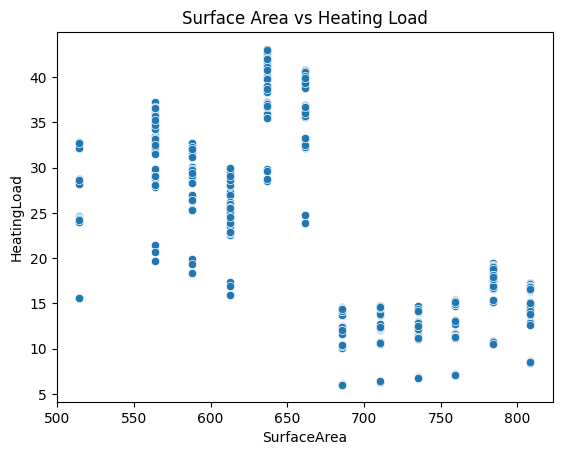

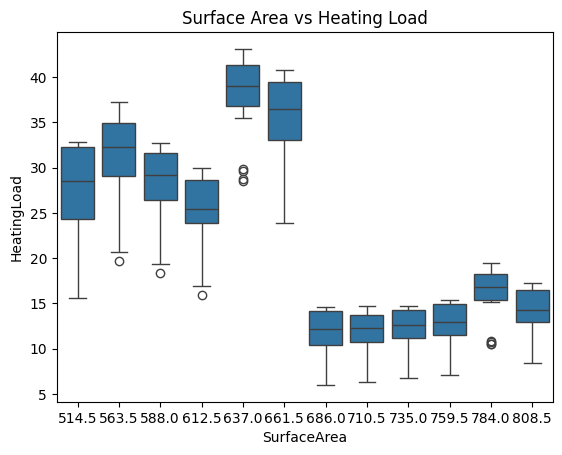

In [149]:
SurfaceArea = data["SurfaceArea"]
HeatingLoad = data["HeatingLoad"]

sns.scatterplot(x="SurfaceArea", y="HeatingLoad", data=data)
plt.title("Surface Area vs Heating Load")
plt.show()

sns.boxplot(x="SurfaceArea", y="HeatingLoad", data=data)
plt.title("Surface Area vs Heating Load")
plt.show()

## 2. Correlation Analysis

In [150]:
correlation = SurfaceArea.corr(HeatingLoad, method='spearman')
print("Correlation between Surface Area and Heating Load:", correlation)

Correlation between Surface Area and Heating Load: -0.6221346966316251


## 3. Scatterplot with OverallHeight Hue

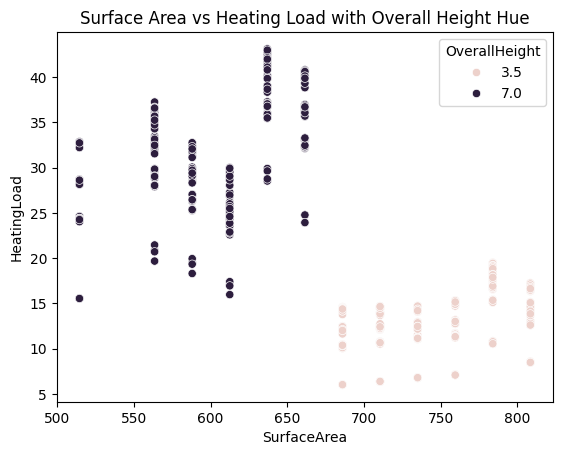

In [151]:
sns.scatterplot(x="SurfaceArea", y="HeatingLoad", hue="OverallHeight", data=data)
plt.title("Surface Area vs Heating Load with Overall Height Hue")
plt.show()

## 4. Train Linear Regression Model

In [152]:
# Add constant term (intercept)
X = sm.add_constant(SurfaceArea)

# Verify the relationship
print("Correlation:", SurfaceArea.corr(HeatingLoad))
print("\nFirst few values:")
print("SurfaceArea:", SurfaceArea.head().values)
print("HeatingLoad:", HeatingLoad.head().values)

linreg_statsm = sm.OLS(HeatingLoad, X).fit()

Correlation: -0.6581202267776216

First few values:
SurfaceArea: [514.5 514.5 514.5 514.5 563.5]
HeatingLoad: [15.55 15.55 15.55 15.55 20.84]


## 5. Model Summary and Coefficients

In [153]:
print(linreg_statsm.summary())

b = linreg_statsm.params
print("\nModel Coefficients:")
print(b)

                            OLS Regression Results                            
Dep. Variable:            HeatingLoad   R-squared:                       0.433
Model:                            OLS   Adj. R-squared:                  0.432
Method:                 Least Squares   F-statistic:                     585.3
Date:                Sat, 14 Mar 2026   Prob (F-statistic):           1.69e-96
Time:                        16:40:33   Log-Likelihood:                -2646.6
No. Observations:                 768   AIC:                             5297.
Df Residuals:                     766   BIC:                             5306.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          72.9454      2.111     34.554      

## 6. Regression Line Visualization

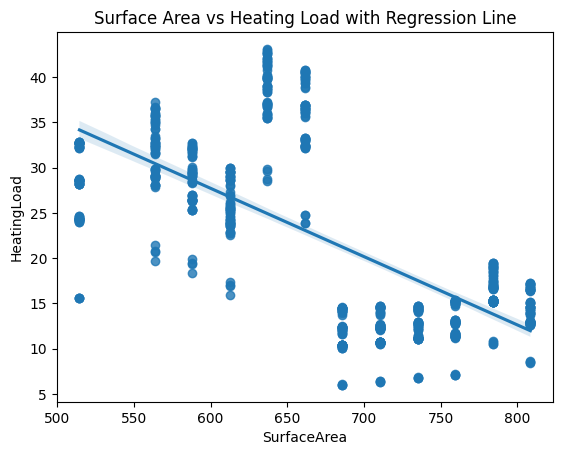

In [154]:
sns.regplot(x="SurfaceArea", y="HeatingLoad", data=data)
plt.title("Surface Area vs Heating Load with Regression Line")
plt.show()

## 7. Model Evaluation

In [155]:
print("R-squared:", linreg_statsm.rsquared)
print("Adjusted R-squared:", linreg_statsm.rsquared_adj)
print("\nMean Absolute Error (MAE):", np.mean(np.abs(linreg_statsm.resid)))
print("Mean Squared Error (MSE):", np.mean(linreg_statsm.resid**2))

R-squared: 0.433122232893828
Adjusted R-squared: 0.43238218358951186

Mean Absolute Error (MAE): 6.002338517195692
Mean Squared Error (MSE): 57.63983779426345


---
# 5. Time Series

**Exercise:** Tasks 3, 4, and 6 from TSA_Task
- Clean dataset
- Create at least 5 new features with justification
- Train XGBoost model
- Explain train/test/validation split
- Calculate RMSE and MAE evaluation metrics

In [156]:
# Download bike sharing dataset
path = kagglehub.dataset_download("lakshmi25npathi/bike-sharing-dataset")
print("Path to dataset files:", path)

files = os.listdir(path)
print("Files in dataset:", files)

hour = pd.read_csv(os.path.join(path, "hour.csv"))
print("\nFirst 5 records:")
hour.head()

Path to dataset files: /home/xilas/.cache/kagglehub/datasets/lakshmi25npathi/bike-sharing-dataset/versions/1
Files in dataset: ['hour.csv', 'Readme.txt', 'day.csv']

First 5 records:


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


## Data Cleaning and Exploration

In [157]:
# Check for missing values
print("Missing values:")
print(hour.isnull().sum())

# Dataset info
print("\nDataset info:")
hour.info()

# Convert date column
hour["dteday"] = pd.to_datetime(hour["dteday"])

# Check duplicates
print("\nDuplicates:", hour.duplicated().sum())

# Descriptive statistics
print("\nDescriptive statistics:")
print(hour.describe())

Missing values:
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  str    
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum    

## Feature Engineering

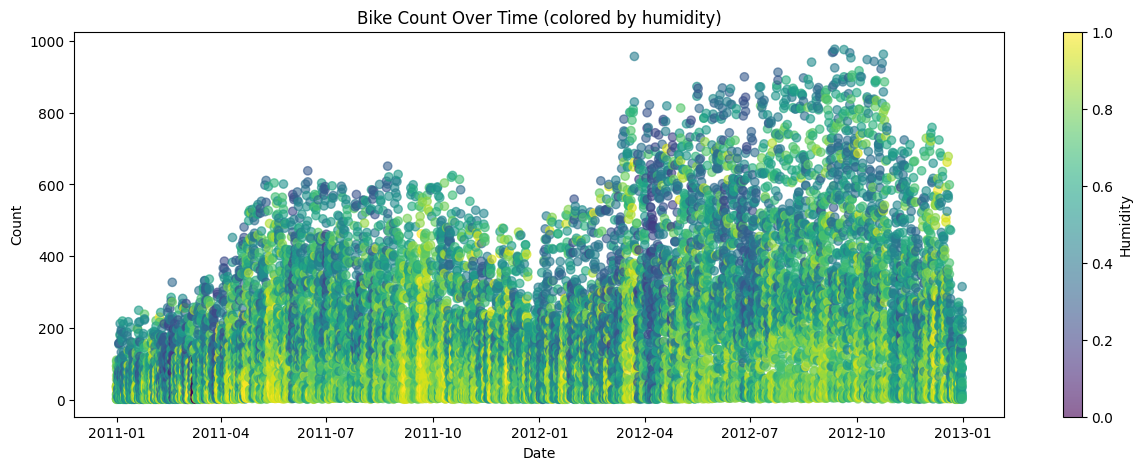

In [158]:
# Create datetime features
hour["datetime_obj"] = pd.to_datetime(hour["dteday"])
hour["Day"] = hour["datetime_obj"].dt.hour
hour["Week"] = hour["datetime_obj"].dt.dayofweek
hour["Month"] = hour["datetime_obj"].dt.month
hour["Year"] = hour["datetime_obj"].dt.year

# Visualize bike counts over time
plt.figure(figsize=(15, 5))
plt.scatter(hour["dteday"], hour["cnt"], c=hour["hum"], cmap="viridis", alpha=0.6)
plt.colorbar(label="Humidity")
plt.xlabel("Date")
plt.ylabel("Count")
plt.title("Bike Count Over Time (colored by humidity)")
plt.show()

## Rolling Mean Features

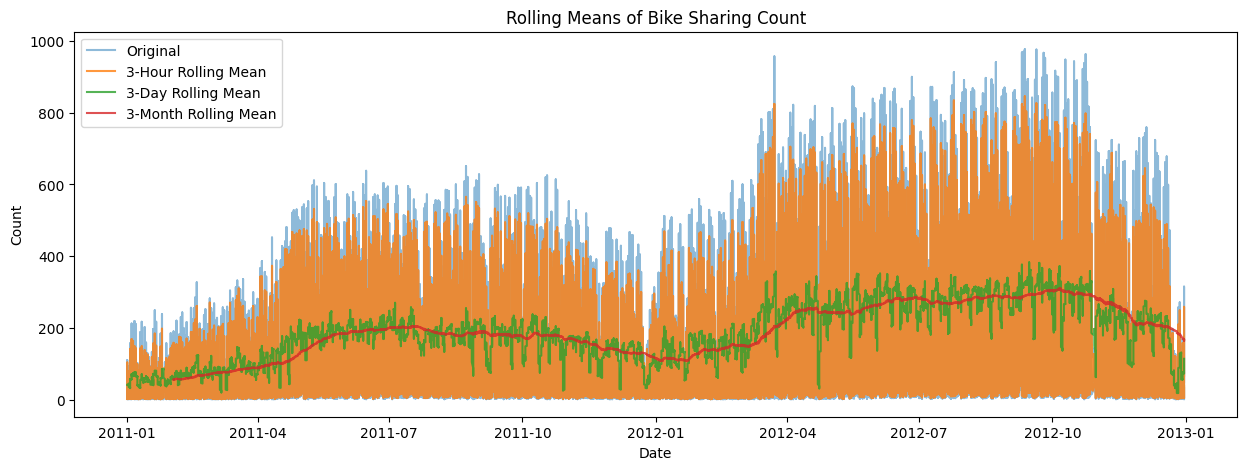

In [159]:
# Create rolling mean features
last_3_hour_rolling_mean = hour["cnt"].rolling(window=3).mean()
last_3_day_rolling_mean = hour["cnt"].rolling(window=24).mean()
last_3_month_rolling_mean = hour["cnt"].rolling(window=24*30).mean()

# Visualize rolling means
plt.figure(figsize=(15, 5))
plt.plot(hour["dteday"], hour["cnt"], label="Original", alpha=0.5)
plt.plot(hour["dteday"], last_3_hour_rolling_mean, label="3-Hour Rolling Mean", alpha=0.8)
plt.plot(hour["dteday"], last_3_day_rolling_mean, label="3-Day Rolling Mean", alpha=0.8)
plt.plot(hour["dteday"], last_3_month_rolling_mean, label="3-Month Rolling Mean", alpha=0.8)
plt.xlabel("Date")
plt.ylabel("Count")
plt.title("Rolling Means of Bike Sharing Count")
plt.legend()
plt.show()

## Lag Features & XGBoost Model


Train: 12,047 | Val: 2,582 | Test: 2,582



XGBoost Test Metrics:
  RMSE: 47.36
  MAE:  27.79


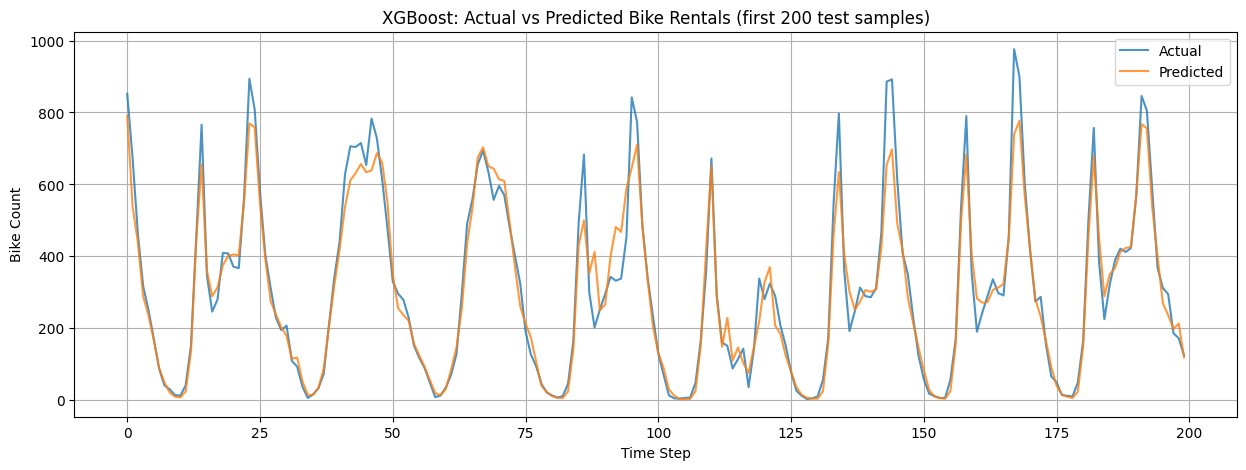

In [160]:
# Work on a copy so we don't pollute the original 'hour' DataFrame
hour_ml = hour.copy()

# Lag features — justification:
#   lag_1h:   very recent demand; strongest short-term signal
#   lag_24h:  same hour yesterday; captures daily seasonality
#   lag_168h: same hour last week; captures weekly seasonality
#   rolling_3h:  smoothed short-term trend (noise reduction)
#   rolling_24h: smoothed daily trend
hour_ml["lag_1h"]       = hour_ml["cnt"].shift(1)
hour_ml["lag_24h"]      = hour_ml["cnt"].shift(24)
hour_ml["lag_168h"]     = hour_ml["cnt"].shift(168)
hour_ml["rolling_3h"]   = hour_ml["cnt"].rolling(window=3).mean()
hour_ml["rolling_24h"]  = hour_ml["cnt"].rolling(window=24).mean()
hour_ml = hour_ml.dropna()

# Feature set — drop target, sub-components of cnt, and non-numeric date cols
features = [c for c in hour_ml.columns if c not in
            ["cnt", "casual", "registered", "dteday", "instant", "datetime_obj"]]

X_ts = hour_ml[features]
Y_ts = hour_ml["cnt"]

# Chronological 70 / 15 / 15 split
# Must be chronological (not random) to preserve time order and prevent future data leakage
n = len(hour_ml)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

X_train_ts, Y_train_ts = X_ts.iloc[:train_end],  Y_ts.iloc[:train_end]
X_val_ts,   Y_val_ts   = X_ts.iloc[train_end:val_end], Y_ts.iloc[train_end:val_end]
X_test_ts,  Y_test_ts  = X_ts.iloc[val_end:],    Y_ts.iloc[val_end:]

print(f"Train: {len(X_train_ts):,} | Val: {len(X_val_ts):,} | Test: {len(X_test_ts):,}")

# Train XGBoost
xgb = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42)
xgb.fit(X_train_ts, Y_train_ts, eval_set=[(X_val_ts, Y_val_ts)], verbose=False)

# Evaluate
Y_pred_xgb = xgb.predict(X_test_ts)
rmse = np.sqrt(mean_squared_error(Y_test_ts, Y_pred_xgb))
mae  = mean_absolute_error(Y_test_ts, Y_pred_xgb)
print(f"\nXGBoost Test Metrics:\n  RMSE: {rmse:.2f}\n  MAE:  {mae:.2f}")

# Plot first 200 test predictions
plt.figure(figsize=(15, 5))
plt.plot(Y_test_ts.values[:200], label="Actual", alpha=0.8)
plt.plot(Y_pred_xgb[:200],      label="Predicted", alpha=0.8)
plt.title("XGBoost: Actual vs Predicted Bike Rentals (first 200 test samples)")
plt.xlabel("Time Step")
plt.ylabel("Bike Count")
plt.legend()
plt.grid()
plt.show()


---
# 6. Classification

**Exercise 2:** KNN Classifier on Titanic Dataset

Tasks:
1. Load titanic dataset, select features and target
2. Handle missing values
3. Create dummy variables
4. Train-test split (20%, random_state=962)
5. Scale data
6. Train KNN models for multiple K values (2-50)
7. Plot train/test precision and recall
8. Select best K for precision and recall
9. Create confusion matrices and calculate metrics

In [161]:
# Load titanic dataset
titanic_data = pd.read_csv("Data/titanic_survival_data.csv")
titanic_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.250,S
1,1,1,female,38.0,1,0,712.833,C
2,1,3,female,26.0,0,0,7.925,S
3,1,1,female,35.0,1,0,53.100,S
4,0,3,male,35.0,0,0,8.050,S


## Data Preparation

In [162]:
# Select features and target
X = titanic_data[["Pclass", "Sex", "Age", "Fare"]]
Y = titanic_data["Survived"]

# Fill missing values with mean
X["Age"] = X["Age"].fillna(X["Age"].mean())
X["Fare"] = X["Fare"].fillna(X["Fare"].mean())

# Get dummies for categorical columns
X = pd.get_dummies(X, columns=["Sex", "Pclass"])
X.head()

,Age,Fare,Sex_female,Sex_male,Pclass_1,Pclass_2,Pclass_3
0,22.0,7.250,False,True,False,False,True
1,38.0,712.833,True,False,True,False,False
2,26.0,7.925,True,False,False,False,True
3,35.0,53.100,True,False,True,False,False
4,35.0,8.050,False,True,False,False,True


## Train-Test Split and Scaling

In [163]:
# Train-test split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=962)

# Scale the data
scaler = sklearn.preprocessing.StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

X_train_scaled.head()

,Age,Fare,Sex_female,Sex_male,Pclass_1,Pclass_2,Pclass_3
109,-0.001709,-0.417652,1.389259,-1.389259,-0.575188,-0.520988,0.926827
622,-0.749967,0.432741,-0.719808,0.719808,-0.575188,-0.520988,0.926827
789,1.259968,-0.066371,-0.719808,0.719808,1.738562,-0.520988,-1.078950
562,-0.131525,-0.485611,-0.719808,0.719808,-0.575188,1.919430,-1.078950
75,-0.363441,-0.522940,-0.719808,0.719808,-0.575188,-0.520988,0.926827


## Train KNN Models for Multiple K Values

In [164]:
# Train KNN models for k from 2 to 50
k_values = range(2, 51)
train_accuracies = []
test_accuracies = []
train_precisions = []
test_precisions = []
train_recalls = []
test_recalls = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, Y_train)
    
    Y_train_pred = knn.predict(X_train_scaled)
    Y_test_pred = knn.predict(X_test_scaled)
    
    train_accuracies.append(accuracy_score(Y_train, Y_train_pred))
    test_accuracies.append(accuracy_score(Y_test, Y_test_pred))
    
    train_precisions.append(precision_score(Y_train, Y_train_pred))
    test_precisions.append(precision_score(Y_test, Y_test_pred))
    
    train_recalls.append(recall_score(Y_train, Y_train_pred))
    test_recalls.append(recall_score(Y_test, Y_test_pred))

print("Training complete for k = 2 to 50")

Training complete for k = 2 to 50


## Visualize Precision and Recall

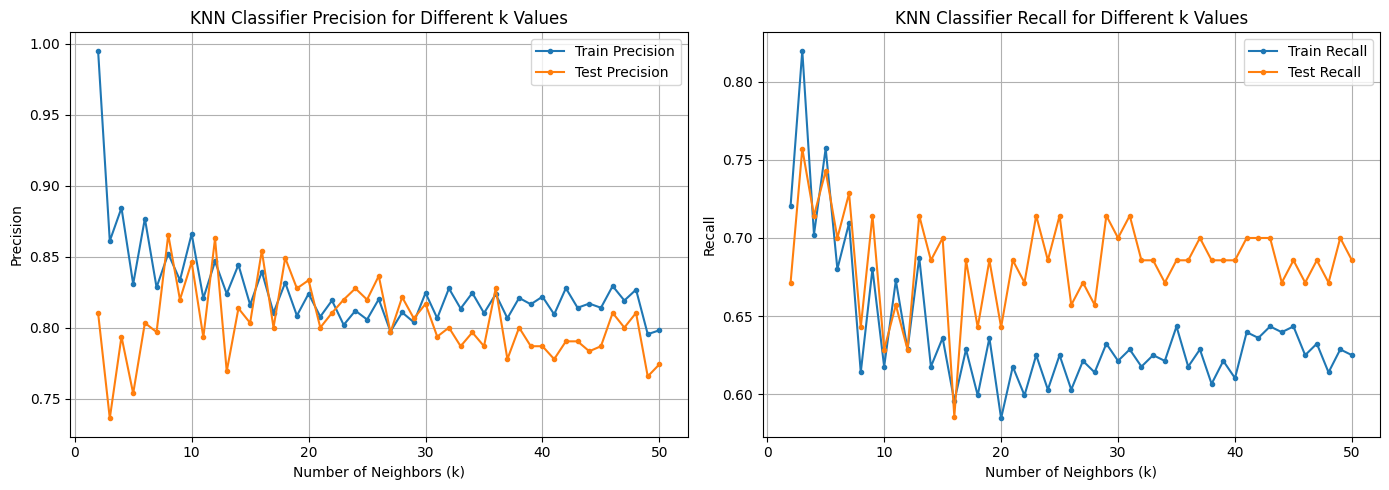

In [165]:
# Plot train and test precision and recall
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precision plot
axes[0].plot(k_values, train_precisions, marker='o', label='Train Precision', markersize=3)
axes[0].plot(k_values, test_precisions, marker='o', label='Test Precision', markersize=3)
axes[0].set_xlabel('Number of Neighbors (k)')
axes[0].set_ylabel('Precision')
axes[0].set_title('KNN Classifier Precision for Different k Values')
axes[0].legend()
axes[0].grid()

# Recall plot
axes[1].plot(k_values, train_recalls, marker='o', label='Train Recall', markersize=3)
axes[1].plot(k_values, test_recalls, marker='o', label='Test Recall', markersize=3)
axes[1].set_xlabel('Number of Neighbors (k)')
axes[1].set_ylabel('Recall')
axes[1].set_title('KNN Classifier Recall for Different k Values')
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

## Find Best K Values

In [166]:
# Find best k for precision and recall (k > 5)
best_precision_k = list(k_values)[np.argmax(test_precisions[4:])] + 4
best_recall_k = list(k_values)[np.argmax(test_recalls[4:])] + 4

print(f"Best k for precision (k > 5): {best_precision_k} with precision = {max(test_precisions[4:]):.4f}")
print(f"Best k for recall (k > 5): {best_recall_k} with recall = {max(test_recalls[4:]):.4f}")

Best k for precision (k > 5): 8 with precision = 0.8654
Best k for recall (k > 5): 7 with recall = 0.7286


## Train Final Models

In [167]:
# Train final models with best k values
knn_best_precision = KNeighborsClassifier(n_neighbors=best_precision_k)
knn_best_precision.fit(X_train_scaled, Y_train)

knn_best_recall = KNeighborsClassifier(n_neighbors=best_recall_k)
knn_best_recall.fit(X_train_scaled, Y_train)

print(f"Models trained for k={best_precision_k} (best precision) and k={best_recall_k} (best recall)")

Models trained for k=8 (best precision) and k=7 (best recall)


## Confusion Matrices

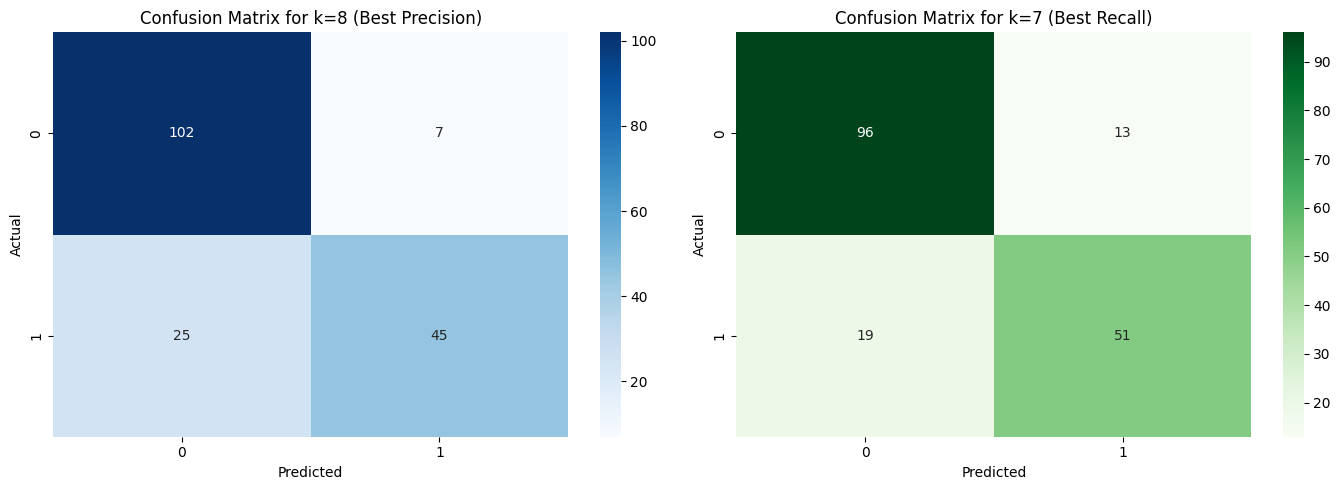

In [168]:
# Confusion matrices
Y_test_pred_precision = knn_best_precision.predict(X_test_scaled)
Y_test_pred_recall = knn_best_recall.predict(X_test_scaled)

cm_precision = confusion_matrix(Y_test, Y_test_pred_precision)
cm_recall = confusion_matrix(Y_test, Y_test_pred_recall)

# Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm_precision, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'Confusion Matrix for k={best_precision_k} (Best Precision)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_recall, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title(f'Confusion Matrix for k={best_recall_k} (Best Recall)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

---
# 7. IoT and Sensor Data

**Exercise i:** MQTT with Diabetes Dataset (from slide 16, bullet 2)
**Exercise ii:** PCA Analysis (from pdm_task)

Tasks for PCA:
1. Apply PCA with up to 5 components
2. Visualize variance explained by each component
3. Visualize first 2 principal components colored by timestep
4. Simulate a new position
5. Plot new point in original 2D PCA graph

## PCA Analysis on Simulated Sensor Data

In [169]:
# Step 1: Simulate synthetic predictive maintenance dataset
np.random.seed(42)
time_steps = 10000

sensors = {}
for i in range(1, 21):
    sensors[f'Sensor{i}'] = np.linspace(50, 100, time_steps) + np.random.normal(0, 20, time_steps)

# Combine into a DataFrame
sensor_data = pd.DataFrame(sensors)
print("Sample Data:")
print(sensor_data.head())

Sample Data:
     Sensor1    Sensor2    Sensor3    Sensor4    Sensor5    Sensor6  \
0  59.934283  36.430105  56.965725  10.388561  40.562849  51.964123   
1  47.239714  43.895011  55.671472  28.905288  70.259050  48.722836   
2  62.963772  38.062380  31.279604  38.269433  46.046264  69.045816   
3  80.475599  52.223362  61.606686  53.008380  51.826387  80.671624   
4  45.336935  73.963573  20.218348  70.503249  64.367814  63.756941   

     Sensor7    Sensor8    Sensor9   Sensor10   Sensor11   Sensor12  \
0  51.576755  56.403048  63.280022  69.217891  70.611892  66.017477   
1  61.262950  72.314233  44.082680  42.605706  26.897905  49.021813   
2  56.832040  19.905237  48.678273  38.418383  61.518745  41.079748   
3  24.456718  84.807115  46.507354  68.681245  37.630232  53.375301   
4  46.295596  56.621738  60.301076  -4.610793  43.471946   7.484493   

    Sensor13   Sensor14   Sensor15   Sensor16   Sensor17   Sensor18  \
0  45.626995  72.350652  44.689254  77.397560  78.652455  13.5

In [170]:
# Step 2: Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(sensor_data)

print("Scaled Data Sample:")
print(pd.DataFrame(scaled_data, columns=sensor_data.columns).head())

Scaled Data Sample:
    Sensor1   Sensor2   Sensor3   Sensor4   Sensor5   Sensor6   Sensor7  \
0 -0.610580 -1.566006 -0.725010 -2.596654 -1.407431 -0.927666 -0.969437   
1 -1.126525 -1.265030 -0.777771 -1.850742 -0.198347 -1.057996 -0.572396   
2 -0.487452 -1.500195 -1.772111 -1.473524 -1.184173 -0.240819 -0.754021   
3  0.224281 -0.929241 -0.535820 -0.879792 -0.948835  0.226649 -2.081098   
4 -1.203859 -0.052701 -2.223025 -0.175043 -0.438209 -0.453482 -1.185914   

    Sensor8   Sensor9  Sensor10  Sensor11  Sensor12  Sensor13  Sensor14  \
0 -0.746813 -0.479506 -0.232249 -0.186682 -0.367113 -1.184181 -0.110562   
1 -0.106939 -1.258090 -1.320570 -1.955170 -1.054209 -0.697301 -0.772550   
2 -2.214587 -1.071707 -1.491814 -0.554553 -1.375289 -0.412171 -0.701019   
3  0.395468 -1.159753 -0.254195 -1.520984 -0.878208 -1.964016 -1.982653   
4 -0.738018 -0.600323 -3.251518 -1.284652 -2.733470 -0.924990 -0.686938   

   Sensor15  Sensor16  Sensor17  Sensor18  Sensor19  Sensor20  
0 -1.220616  0

## Task 1: Apply PCA with 5 Components

In [171]:
# Apply PCA with up to 5 components
pca_5 = PCA(n_components=5)
pca_5_result = pca_5.fit_transform(scaled_data)

# Print explained variance ratio for each component
print("Explained variance ratio for each component:")
for i, ratio in enumerate(pca_5.explained_variance_ratio_):
    print(f"Component {i+1}: {ratio:.4f}")

Explained variance ratio for each component:
Component 1: 0.3769
Component 2: 0.0359
Component 3: 0.0351
Component 4: 0.0349
Component 5: 0.0343


## Task 2: Visualize Variance Explained

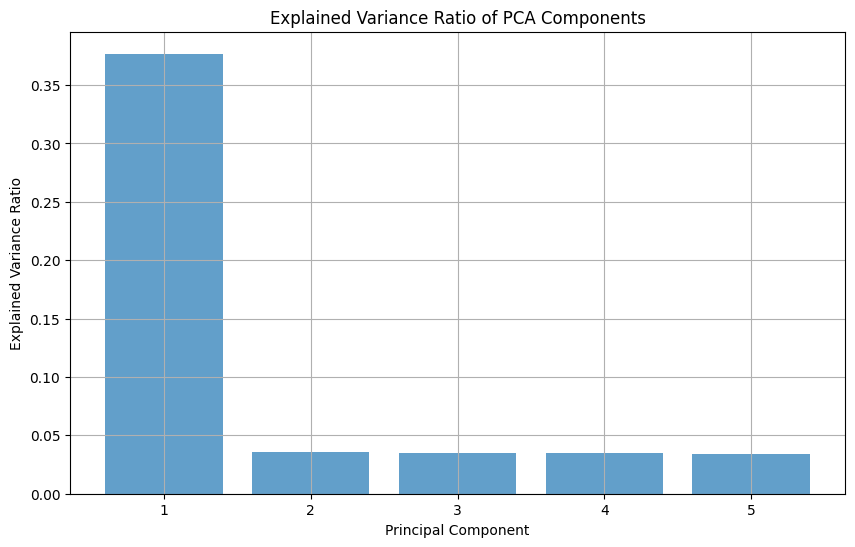

In [172]:
# Visualize how much variance is defined by each component
plt.figure(figsize=(10, 6))
plt.bar(range(1, 6), pca_5.explained_variance_ratio_, alpha=0.7)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance Ratio of PCA Components")
plt.grid()
plt.show()

## Task 3: Visualize 2D PCA

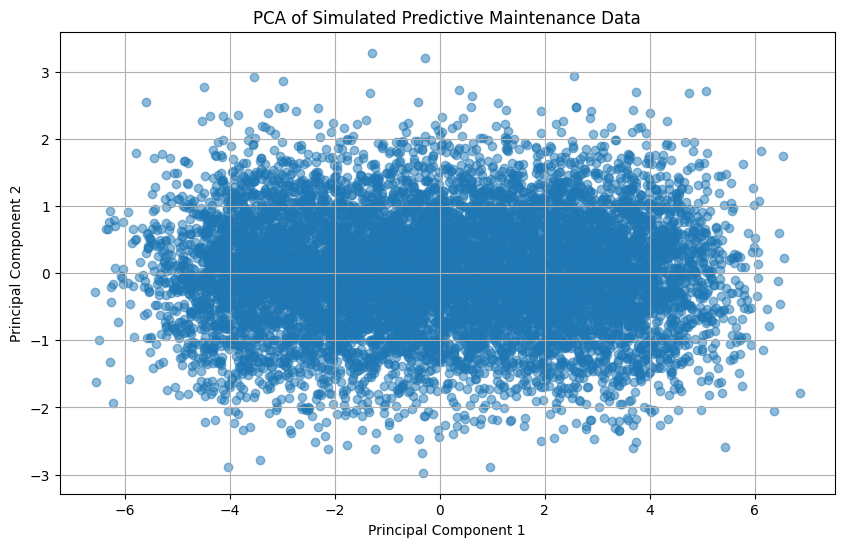

In [173]:
# Apply PCA with 2 components for visualization
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

# Plot the PCA results
plt.figure(figsize=(10, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.5)
plt.title("PCA of Simulated Predictive Maintenance Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid()
plt.show()

## Task 4 & 5: Simulate New Point and Plot

In [174]:
# Create a new point with 20 sensor values
new_point = {}
for i in range(1, 21):
    new_point[f'Sensor{i}'] = np.random.uniform(50, 100) + np.random.normal(0, 20)

new_point_df = pd.DataFrame([new_point])
print("New simulated point:")
print(new_point_df)

# Scale and transform
new_point_scaled = scaler.transform(new_point_df)
new_point_transformed = pca.transform(new_point_scaled)
print("\nPCA-transformed new simulated point:")
print(new_point_transformed)

New simulated point:
    Sensor1    Sensor2    Sensor3    Sensor4     Sensor5     Sensor6  \
0  71.11035  77.718551  46.423748  84.290088  113.050647  102.042586   

     Sensor7    Sensor8    Sensor9   Sensor10   Sensor11   Sensor12  \
0  76.312061  83.300693  47.912127  75.908431  56.108257  84.615147   

    Sensor13    Sensor14   Sensor15   Sensor16  Sensor17  Sensor18   Sensor19  \
0  75.992426  107.482718  71.607757  97.585286  91.28264  77.46756  87.564371   

     Sensor20  
0  110.972088  

PCA-transformed new simulated point:
[[ 1.24199703 -0.76560423]]


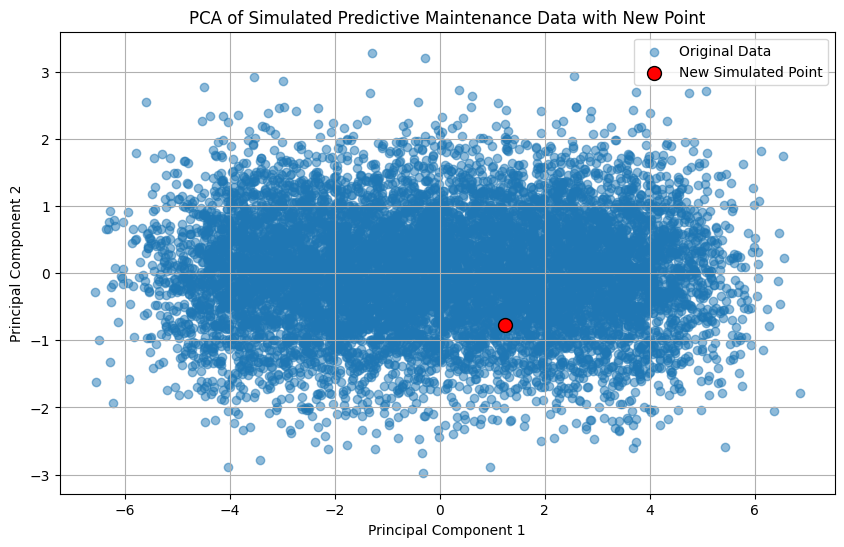

In [175]:
# Plot new point on PCA graph
plt.figure(figsize=(10, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.5, label="Original Data")
plt.scatter(new_point_transformed[0, 0], new_point_transformed[0, 1], 
           color='red', label="New Simulated Point", edgecolor='black', s=100)
plt.title("PCA of Simulated Predictive Maintenance Data with New Point")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid()
plt.show()

## MQTT Exercise with Diabetes Dataset

In [176]:
# Load and prepare diabetes data
diabetes = pd.read_csv("Data/diabetes.csv")
diabetes_isolated = diabetes[["Glucose", "BloodPressure", "Insulin", "Outcome"]]

# Scale features to [0, 1]
scaler = MinMaxScaler()
diabetes_scaled = pd.DataFrame(scaler.fit_transform(diabetes_isolated.drop("Outcome", axis=1)), 
                               columns=diabetes_isolated.columns[:-1])
diabetes_scaled["Outcome"] = diabetes_isolated["Outcome"]

print("Scaled diabetes data:")
print(diabetes_scaled.head())

Scaled diabetes data:
    Glucose  BloodPressure   Insulin  Outcome
0  0.743719       0.590164  0.000000        1
1  0.427136       0.540984  0.000000        0
2  0.919598       0.524590  0.000000        1
3  0.447236       0.540984  0.111111        0
4  0.688442       0.327869  0.198582        1


In [177]:
TOPIC = "jwsc/diabetes/sensors"
BROKER = "broker.hivemq.com"
PORT = 1883
received_data = []

def on_connect(client, userdata, flags, rc):
    if rc == 0:
        print("Subscriber connected!")
        client.subscribe(TOPIC)

def on_message(client, userdata, msg):
    payload = msg.payload.decode()
    received_data.append(payload)
    print(f"[Received] {payload}")

# Start subscriber in background thread
subscriber = mqtt.Client(client_id="jwsc_subscriber")
subscriber.on_connect = on_connect
subscriber.on_message = on_message
subscriber.connect(BROKER, PORT, 60)
subscriber.loop_start()
time.sleep(2)

# Publisher: send rows from diabetes_scaled over MQTT
publisher = mqtt.Client(client_id="jwsc_publisher")
publisher.connect(BROKER, PORT, 60)

print("Publishing 5 diabetes sensor readings...")
for i in range(5):
    row = diabetes_scaled.iloc[i][["Glucose", "BloodPressure", "Insulin"]].to_dict()
    payload = str({k: round(v, 4) for k, v in row.items()})
    publisher.publish(TOPIC, payload)
    print(f"[Published] {payload}")
    time.sleep(1)

time.sleep(3)
subscriber.loop_stop()
subscriber.disconnect()
publisher.disconnect()
print(f"\nTotal messages received: {len(received_data)}")


/tmp/ipykernel_3896/403828050.py:17: DeprecationWarning: Callback API version 1 is deprecated, update to latest version
  subscriber = mqtt.Client(client_id="jwsc_subscriber")


Subscriber connected!


/tmp/ipykernel_3896/403828050.py:25: DeprecationWarning: Callback API version 1 is deprecated, update to latest version
  publisher = mqtt.Client(client_id="jwsc_publisher")


Publishing 5 diabetes sensor readings...
[Published] {'Glucose': 0.7437, 'BloodPressure': 0.5902, 'Insulin': 0.0}
[Received] {'Glucose': 0.7437, 'BloodPressure': 0.5902, 'Insulin': 0.0}
[Published] {'Glucose': 0.4271, 'BloodPressure': 0.541, 'Insulin': 0.0}
[Received] {'Glucose': 0.4271, 'BloodPressure': 0.541, 'Insulin': 0.0}
[Published] {'Glucose': 0.9196, 'BloodPressure': 0.5246, 'Insulin': 0.0}
[Received] {'Glucose': 0.9196, 'BloodPressure': 0.5246, 'Insulin': 0.0}
[Published] {'Glucose': 0.4472, 'BloodPressure': 0.541, 'Insulin': 0.1111}
[Received] {'Glucose': 0.4472, 'BloodPressure': 0.541, 'Insulin': 0.1111}
[Published] {'Glucose': 0.6884, 'BloodPressure': 0.3279, 'Insulin': 0.1986}
[Received] {'Glucose': 0.6884, 'BloodPressure': 0.3279, 'Insulin': 0.1986}

Total messages received: 5


---
# 8. Clustering

**Exercise 1:** Bike Station Clustering

Tasks:
1. Apply K-Means clustering with different K values using Elbow method
2. Visualize K-Means clustering for best K
3. Apply Agglomerative clustering with dendrogram
4. Visualize Agglomerative clustering
5. Apply DBSCAN with different eps and min_samples
6. Visualize DBSCAN clustering
7. Calculate Silhouette scores and Adjusted Rand Index for comparison

In [178]:
# Load bike station data
bikes = pd.read_csv("Data/Ch5_bike_station_locations.csv")
print(bikes.info())
print(bikes.describe())
bikes.head()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   latitude   244 non-null    float64
 1   longitude  244 non-null    float64
dtypes: float64(2)
memory usage: 3.9 KB
None
         latitude   longitude
count  244.000000  244.000000
mean    38.914289  -77.010109
std      0.035435    0.041084
min     38.827425  -77.106502
25%     38.891574  -77.031987
50%     38.916397  -77.011474
75%     38.935887  -76.985866
max     38.987980  -76.919470


,latitude,longitude
0,38.956590,-76.993437
1,38.905218,-77.001496
2,38.980858,-77.054722
3,38.902925,-76.929915
4,38.949498,-77.093620


## Data Preparation

In [179]:
# Scale the data before clustering
X = bikes[["latitude", "longitude"]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## K-Means Clustering

In [180]:
# Fit K-means with K=3
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)

print("Cluster labels:", kmeans.labels_)
print("Number of points in each cluster:", np.bincount(kmeans.labels_))

Cluster labels: [1 0 2 0 2 2 0 0 0 0 2 0 0 0 1 2 2 1 2 0 0 1 1 0 2 1 2 1 1 0 0 0 1 2 1 2 1
 0 1 1 0 1 2 1 0 1 0 2 0 2 0 1 0 0 0 0 0 0 1 0 2 2 2 1 0 0 0 1 1 1 1 1 1 1
 0 1 1 1 0 2 0 2 2 2 1 2 0 1 0 0 1 0 2 0 0 1 2 0 1 2 1 0 2 2 1 1 2 1 1 1 1
 1 0 1 2 0 1 1 0 1 0 1 2 2 2 0 0 0 0 0 1 1 2 2 1 0 0 0 2 1 1 1 1 2 1 2 2 1
 1 0 2 1 0 1 1 0 2 0 1 1 0 0 0 0 1 0 2 2 1 0 1 1 1 0 2 1 0 1 1 2 0 0 0 2 0
 0 0 2 0 1 0 0 2 1 0 0 0 1 1 1 2 1 2 2 1 0 0 2 1 1 1 0 0 1 1 0 2 1 0 1 1 2
 1 0 1 0 0 1 0 0 1 1 1 2 0 0 0 2 0 2 0 1 0 1]
Number of points in each cluster: [95 93 56]


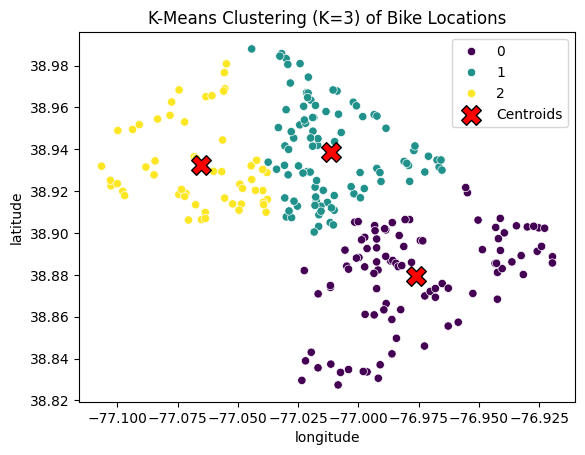

In [181]:
# Visualize the clustering
bikes["3MeansCluster"] = kmeans.labels_

# Transform cluster centers back to original scale
cluster_centers_original = scaler.inverse_transform(kmeans.cluster_centers_)

sns.scatterplot(data=bikes, x="longitude", y="latitude", hue="3MeansCluster", palette="viridis")
plt.scatter(x=cluster_centers_original[:,1], y=cluster_centers_original[:,0], 
           color='red', s=200, marker='X', edgecolor='black', label='Centroids')
plt.title("K-Means Clustering (K=3) of Bike Locations")
plt.legend()
plt.show()

## Elbow Method, Agglomerative & DBSCAN


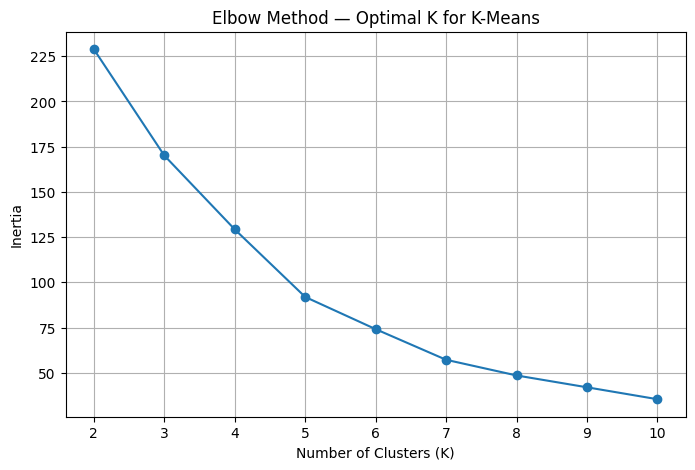

K=3 chosen based on the elbow in the plot above.


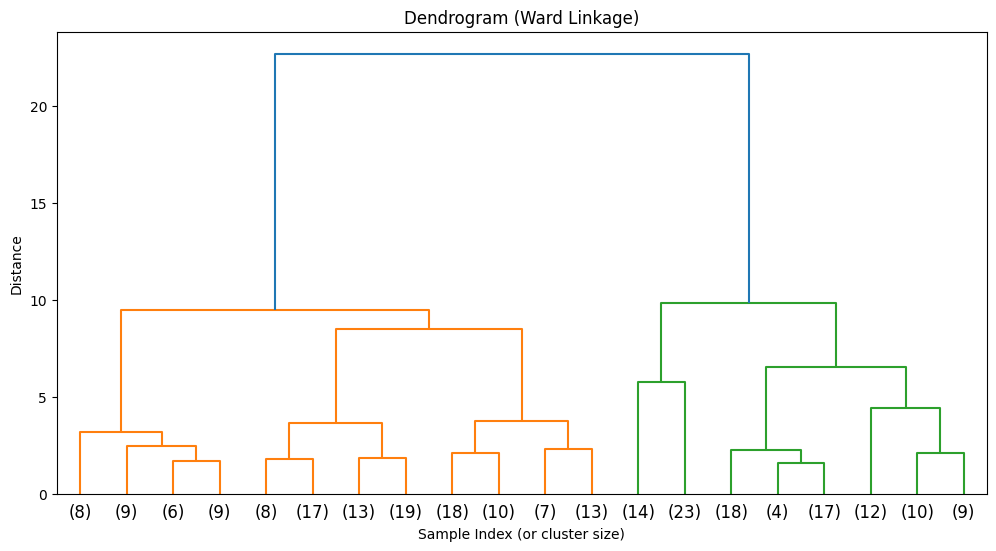

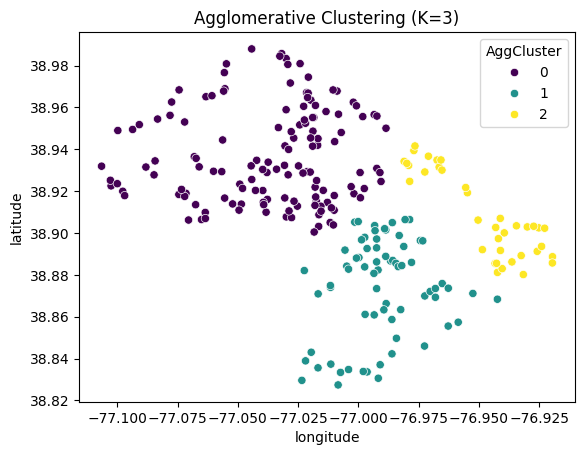

DBSCAN: 0 clusters, 244 noise points


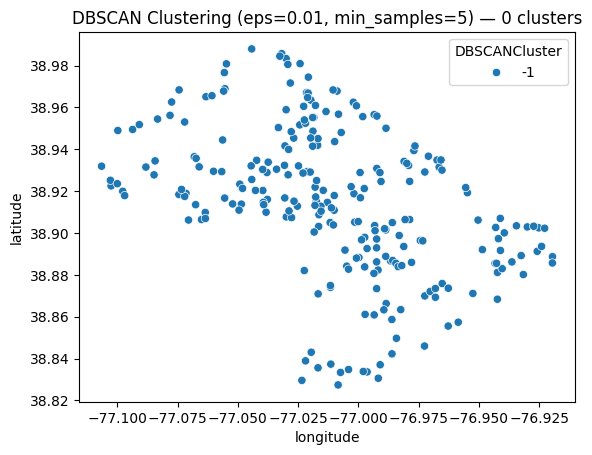

Silhouette Scores (higher = better defined clusters):
  K-Means:        0.3748
  Agglomerative:  0.4150
  DBSCAN: N/A (not enough clusters)

Adjusted Rand Index (1=identical, 0=random, measures agreement between methods):
  K-Means vs Agglomerative: 0.4632
  K-Means vs DBSCAN:        0.0000
  Agglomerative vs DBSCAN:  0.0000


In [182]:
# ── Elbow Method ──────────────────────────────────────────────────────────
inertias = []
for k in range(2, 11):
    km_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_temp.fit(X_scaled)
    inertias.append(km_temp.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertias, marker='o')
plt.title("Elbow Method — Optimal K for K-Means")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.grid()
plt.show()
print("K=3 chosen based on the elbow in the plot above.")

# ── Agglomerative Clustering ──────────────────────────────────────────────
linkage_matrix = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, truncate_mode='lastp', p=20)
plt.title("Dendrogram (Ward Linkage)")
plt.xlabel("Sample Index (or cluster size)")
plt.ylabel("Distance")
plt.show()

agg = AgglomerativeClustering(n_clusters=3)
agg_labels = agg.fit_predict(X_scaled)
bikes["AggCluster"] = agg_labels

sns.scatterplot(data=bikes, x="longitude", y="latitude", hue="AggCluster", palette="viridis")
plt.title("Agglomerative Clustering (K=3)")
plt.show()

# ── DBSCAN ────────────────────────────────────────────────────────────────
dbscan = DBSCAN(eps=0.01, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)
bikes["DBSCANCluster"] = dbscan_labels

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = sum(dbscan_labels == -1)
print(f"DBSCAN: {n_clusters_db} clusters, {n_noise} noise points")

sns.scatterplot(data=bikes, x="longitude", y="latitude", hue="DBSCANCluster", palette="tab10")
plt.title(f"DBSCAN Clustering (eps=0.01, min_samples=5) — {n_clusters_db} clusters")
plt.show()

# ── Silhouette Scores & Adjusted Rand Index ───────────────────────────────
kmeans_labels = bikes["3MeansCluster"].values
sil_kmeans = silhouette_score(X_scaled, kmeans_labels)
sil_agg    = silhouette_score(X_scaled, agg_labels)

print("Silhouette Scores (higher = better defined clusters):")
print(f"  K-Means:        {sil_kmeans:.4f}")
print(f"  Agglomerative:  {sil_agg:.4f}")

valid_mask = dbscan_labels != -1
if len(set(dbscan_labels[valid_mask])) > 1:
    sil_dbscan = silhouette_score(X_scaled[valid_mask], dbscan_labels[valid_mask])
    print(f"  DBSCAN:         {sil_dbscan:.4f} (excluding noise points)")
else:
    print("  DBSCAN: N/A (not enough clusters)")

print("\nAdjusted Rand Index (1=identical, 0=random, measures agreement between methods):")
print(f"  K-Means vs Agglomerative: {adjusted_rand_score(kmeans_labels, agg_labels):.4f}")
print(f"  K-Means vs DBSCAN:        {adjusted_rand_score(kmeans_labels, dbscan_labels):.4f}")
print(f"  Agglomerative vs DBSCAN:  {adjusted_rand_score(agg_labels, dbscan_labels):.4f}")


---
# 9. Machine Learning Operations (MLOps)

**Exercise i:** Complete tasks in mlflow_task.ipynb
**Exercise ii:** Complete tasks 1-6 in MLOps exercises.ipynb

*Note: These exercises require separate notebooks not included in exercises.ipynb*

---
# 10. Social Network Analysis and Large Datasets

**Exercise i:** Write code to turn edge list into adjacency matrix
**Exercise ii:** Calculate degree centrality and betweenness centrality
**Exercise iii:** Compare Pandas and Polars

*Note: These exercises require separate notebooks (01_network_exercise.ipynb, 02_climate_obstruction.ipynb, 03_polars_exercise.ipynb)*

Nodes (6): ['A', 'B', 'C', 'D', 'E', 'F']
Edges (8): [('A', 'B'), ('A', 'C'), ('B', 'D'), ('B', 'E'), ('C', 'D'), ('C', 'F'), ('D', 'E'), ('E', 'A')]


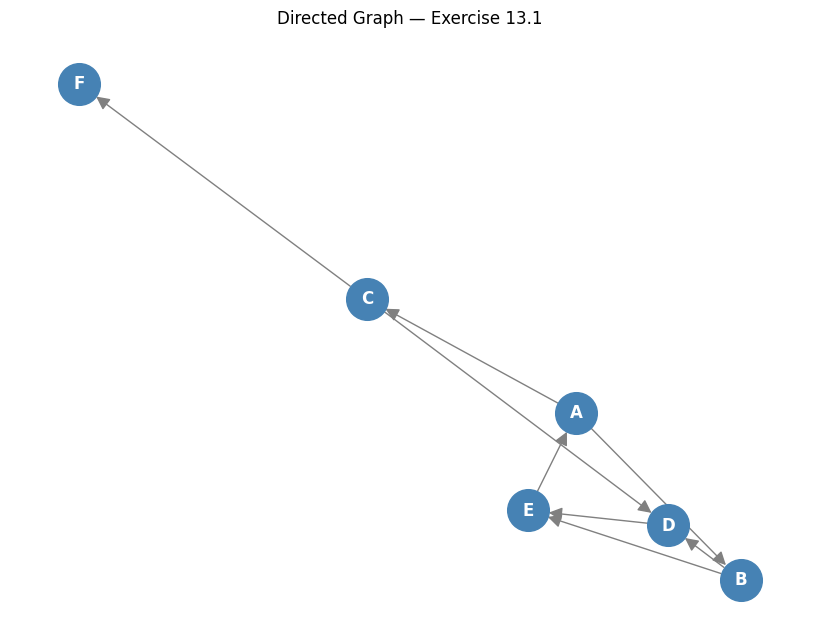


Node degrees:
Node  In-degree  Out-degree
   A          1           2
   B          1           2
   C          1           2
   D          2           1
   E          2           1
   F          1           0

Walk / Trail / Path self-checks:
  ['A', 'B', 'D', 'E']  [valid path]
    is_walk=True  is_trail=True  is_path=True
  ['A', 'B', 'E', 'A', 'C']  [walk: A repeats]
    is_walk=True  is_trail=True  is_path=False
  ['A', 'C', 'D', 'E', 'A']  [trail: no edge repeats, A repeats]
    is_walk=True  is_trail=True  is_path=False
  ['A', 'B', 'A']  [invalid: no B→A edge]
    is_walk=False  is_trail=False  is_path=False


In [183]:

# ── Define nodes and directed edges ────────────────────────────────────────
nodes = ["A", "B", "C", "D", "E", "F"]
edges = [
    ("A", "B"), ("A", "C"), ("B", "D"), ("C", "D"),
    ("D", "E"), ("E", "A"), ("B", "E"), ("C", "F"),
]

G = nx.DiGraph()
G.add_nodes_from(nodes)
G.add_edges_from(edges)
print(f"Nodes ({G.number_of_nodes()}): {list(G.nodes())}")
print(f"Edges ({G.number_of_edges()}): {list(G.edges())}")

# ── Visualise ──────────────────────────────────────────────────────────────
pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(8, 6))
nx.draw(G, pos, with_labels=True, node_color="steelblue", node_size=900,
        font_color="white", font_weight="bold", arrows=True,
        arrowstyle="-|>", arrowsize=20, edge_color="gray")
plt.title("Directed Graph — Exercise 13.1")
plt.show()

# ── In-degree / Out-degree ─────────────────────────────────────────────────
print("\nNode degrees:")
deg_df = pd.DataFrame({
    "Node": list(G.nodes()),
    "In-degree":  [G.in_degree(n)  for n in G.nodes()],
    "Out-degree": [G.out_degree(n) for n in G.nodes()],
})
print(deg_df.to_string(index=False))

# ── Walk / Trail / Path predicates ────────────────────────────────────────
def is_walk(G, path):
    """Any sequence of connected nodes (edges may repeat)."""
    return all(G.has_edge(path[i], path[i + 1]) for i in range(len(path) - 1))

def is_trail(G, path):
    """Walk with no repeated edge."""
    if not is_walk(G, path):
        return False
    edge_seq = [(path[i], path[i + 1]) for i in range(len(path) - 1)]
    return len(edge_seq) == len(set(edge_seq))

def is_path(G, path):
    """Trail with no repeated vertex."""
    return is_trail(G, path) and len(path) == len(set(path))

# Self-checks
test_cases = [
    (["A", "B", "D", "E"],        "valid path"),
    (["A", "B", "E", "A", "C"],   "walk: A repeats"),
    (["A", "C", "D", "E", "A"],   "trail: no edge repeats, A repeats"),
    (["A", "B", "A"],             "invalid: no B→A edge"),
]
print("\nWalk / Trail / Path self-checks:")
for seq, desc in test_cases:
    print(f"  {seq}  [{desc}]")
    print(f"    is_walk={is_walk(G, seq)}  is_trail={is_trail(G, seq)}  is_path={is_path(G, seq)}")


In [184]:

# ── Strong / Weak connected components ────────────────────────────────────
scc = list(nx.strongly_connected_components(G))
wcc = list(nx.weakly_connected_components(G))
print("Strongly connected components (SCCs):")
for i, s in enumerate(scc, 1):
    print(f"  SCC {i}: {s}")
print("\nWeakly connected components (WCCs):")
for i, w in enumerate(wcc, 1):
    print(f"  WCC {i}: {w}")

# ── Adjacency matrix (NetworkX) ────────────────────────────────────────────
A = nx.to_numpy_array(G, nodelist=nodes).astype(int)
A_df = pd.DataFrame(A, index=nodes, columns=nodes)
print("\nAdjacency Matrix A:")
print(A_df)

# ── A² and A³ ─────────────────────────────────────────────────────────────
A2 = np.linalg.matrix_power(A, 2)
A3 = np.linalg.matrix_power(A, 3)
print("\nA² — number of length-2 walks between each pair:")
print(pd.DataFrame(A2, index=nodes, columns=nodes))
print("\nA³ — number of length-3 walks between each pair:")
print(pd.DataFrame(A3, index=nodes, columns=nodes))

# ── Manual adjacency matrix from edge list (no NetworkX) ──────────────────
node_idx = {n: i for i, n in enumerate(nodes)}
A_manual = np.zeros((len(nodes), len(nodes)), dtype=int)
for src, dst in edges:
    A_manual[node_idx[src], node_idx[dst]] = 1
print("\nManual adjacency matrix matches NetworkX:", np.array_equal(A_manual, A))

# ── Save edge list and adjacency matrix to CSV ─────────────────────────────
edge_df = pd.DataFrame(edges, columns=["source", "target"])
edge_df.to_csv("Data/ex13_edge_list.csv", index=False)
pd.DataFrame(A_manual, index=nodes, columns=nodes).to_csv("Data/ex13_adjacency_matrix.csv")
print("Saved: Data/ex13_edge_list.csv & Data/ex13_adjacency_matrix.csv")

# ── Centrality measures ────────────────────────────────────────────────────
deg_centrality = nx.degree_centrality(G)
between_centrality = nx.betweenness_centrality(G)
print("\nDegree Centrality:", {k: round(v, 3) for k, v in deg_centrality.items()})
print("Betweenness Centrality:", {k: round(v, 3) for k, v in between_centrality.items()})


Strongly connected components (SCCs):
  SCC 1: {'F'}
  SCC 2: {'E', 'C', 'B', 'D', 'A'}

Weakly connected components (WCCs):
  WCC 1: {'E', 'C', 'B', 'F', 'D', 'A'}

Adjacency Matrix A:
   A  B  C  D  E  F
A  0  1  1  0  0  0
B  0  0  0  1  1  0
C  0  0  0  1  0  1
D  0  0  0  0  1  0
E  1  0  0  0  0  0
F  0  0  0  0  0  0

A² — number of length-2 walks between each pair:
   A  B  C  D  E  F
A  0  0  0  2  1  1
B  1  0  0  0  1  0
C  0  0  0  0  1  0
D  1  0  0  0  0  0
E  0  1  1  0  0  0
F  0  0  0  0  0  0

A³ — number of length-3 walks between each pair:
   A  B  C  D  E  F
A  1  0  0  0  2  0
B  1  1  1  0  0  0
C  1  0  0  0  0  0
D  0  1  1  0  0  0
E  0  0  0  2  1  1
F  0  0  0  0  0  0

Manual adjacency matrix matches NetworkX: True
Saved: Data/ex13_edge_list.csv & Data/ex13_adjacency_matrix.csv

Degree Centrality: {'A': 0.6, 'B': 0.6, 'C': 0.6, 'D': 0.6, 'E': 0.6, 'F': 0.2}
Betweenness Centrality: {'A': 0.5, 'B': 0.1, 'C': 0.25, 'D': 0.15, 'E': 0.45, 'F': 0.0}


---
# 11. Explainability

**Exercise:** From slide 25 of Explainability.pptx

Tasks:
1. Train at least two models on energy dataset (may use last 5 years)
2. Use SHAP: at least 3 local plots per model + 1 global plot
3. Use LIME: explain 3 rows/predictions
4. Compare SHAP and LIME results

In [185]:
# Using bike sharing dataset from earlier
X = hour.drop(columns=["cnt", "dteday", "datetime_obj"])
Y = hour["cnt"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

## Model 1: Linear Regression

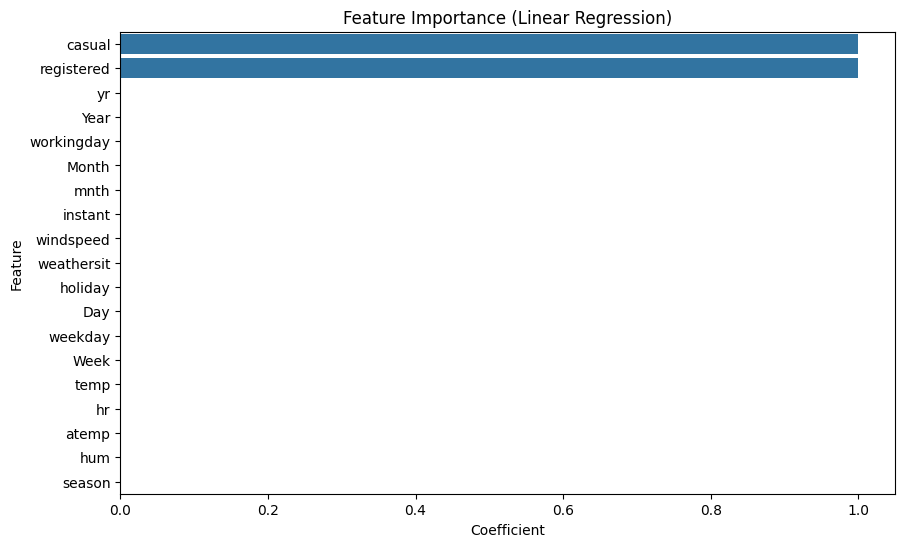

In [186]:
# Train Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train, Y_train)

# Feature importance via correlation
feature_importance = pd.DataFrame({'Feature': X.columns, 'Coefficient': lin_reg.coef_})
feature_importance = feature_importance.sort_values(by='Coefficient', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=feature_importance)
plt.title('Feature Importance (Linear Regression)')
plt.show()

## Model 2: Random Forest

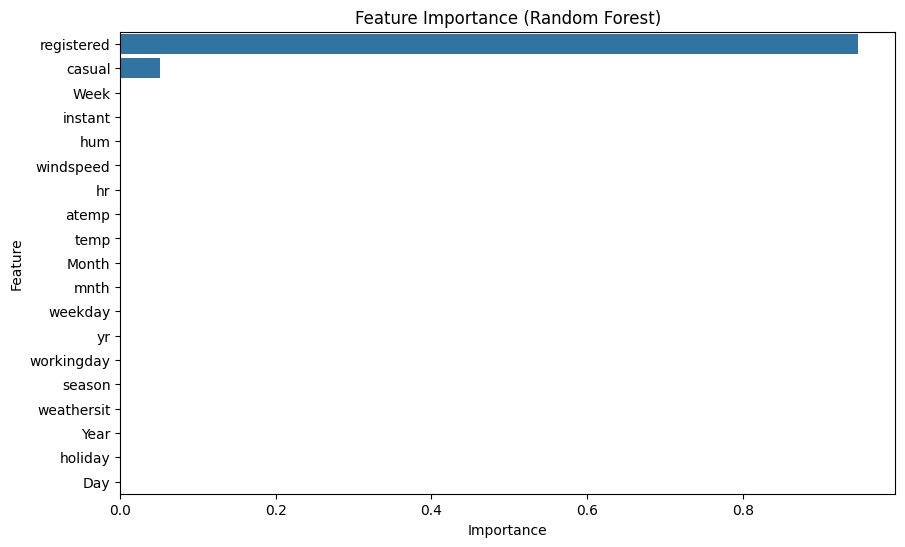

In [187]:
# Train Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, Y_train)

# Feature importance
importances = rf.feature_importances_
feature_importance_rf = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feature_importance_rf = feature_importance_rf.sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_rf)
plt.title('Feature Importance (Random Forest)')
plt.show()

## Partial Dependence Plot

Partial Dependence Plot (PDP) shows how the model's prediction changes as a feature varies.


/home/xilas/DaT/python3venv/lib/python3.12/site-packages/sklearn/inspection/_partial_dependence.py:721: FutureWarning: The column 0 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


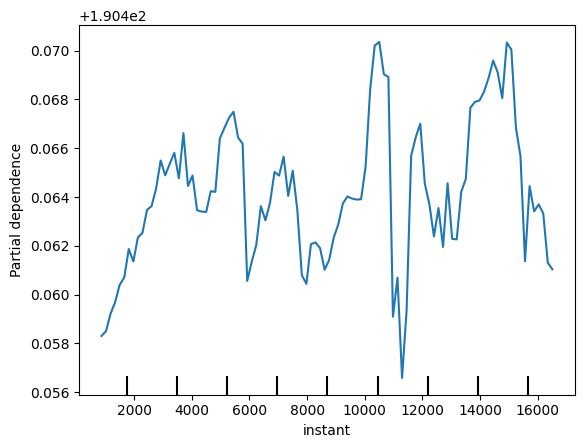

In [188]:
# Partial Dependence Plot
print("Partial Dependence Plot (PDP) shows how the model's prediction changes as a feature varies.")
feature_idx = 0  # Change to visualize different features
PartialDependenceDisplay.from_estimator(rf, X_train, [feature_idx])
plt.show()

## SHAP & LIME Explanations


100%|===================| 3469/3476 [01:09<00:00]        

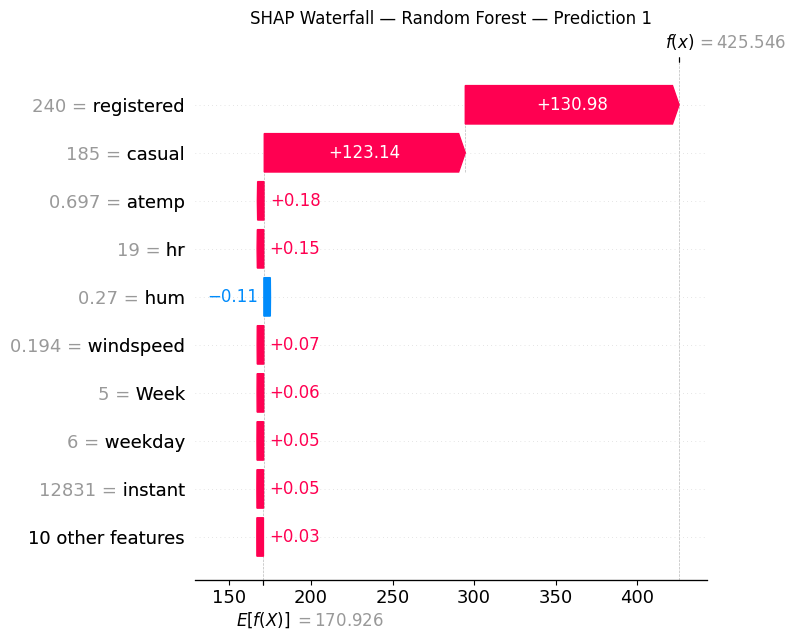

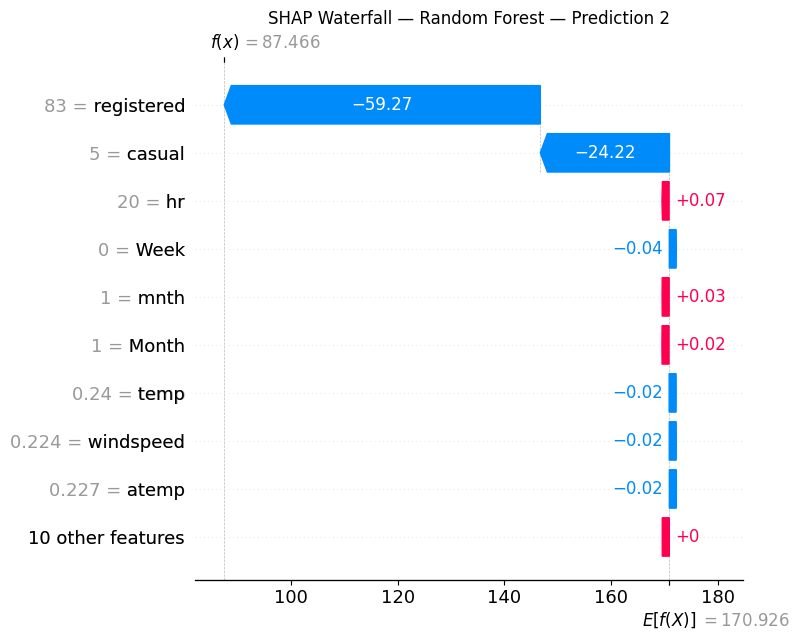

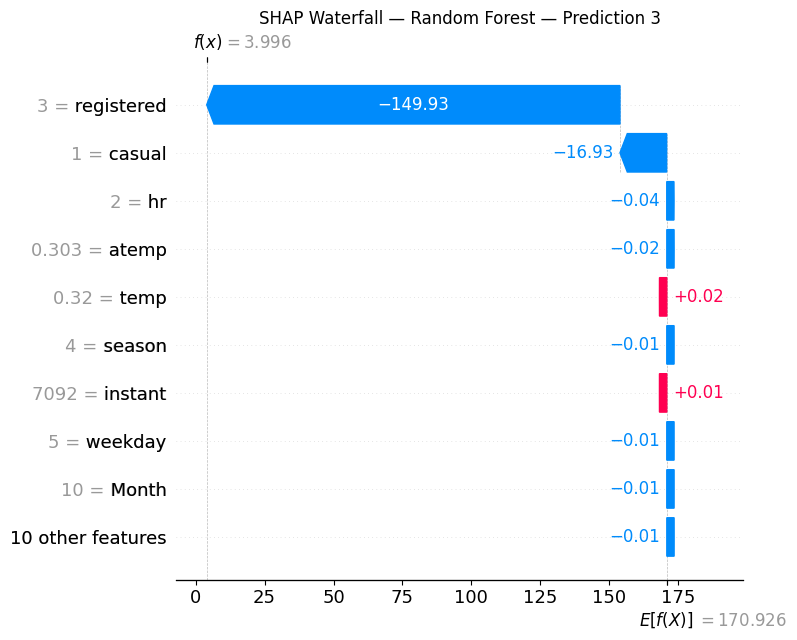

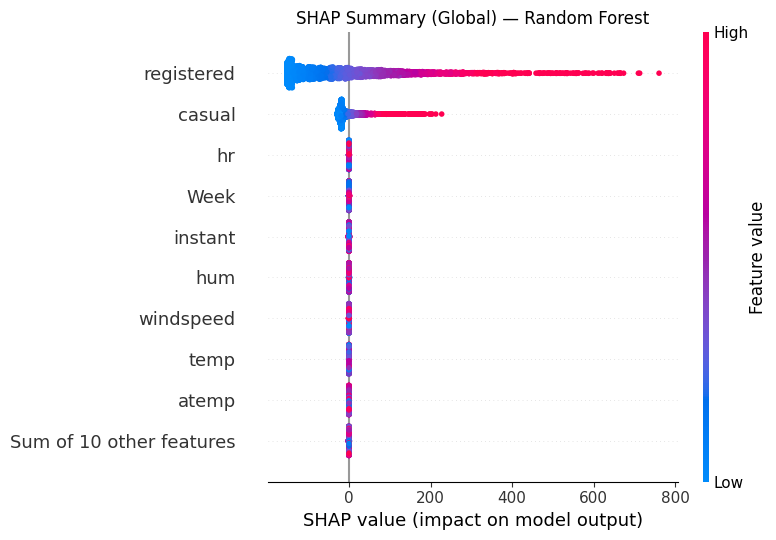

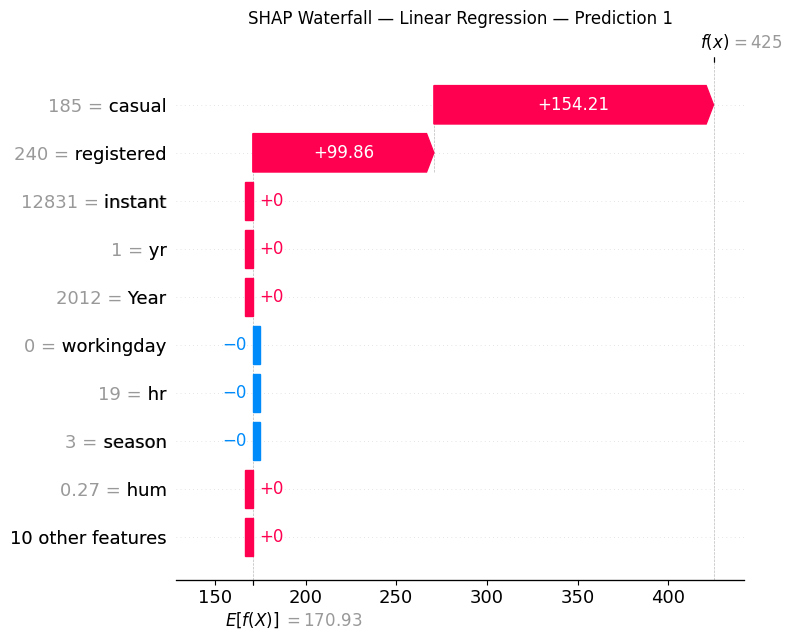

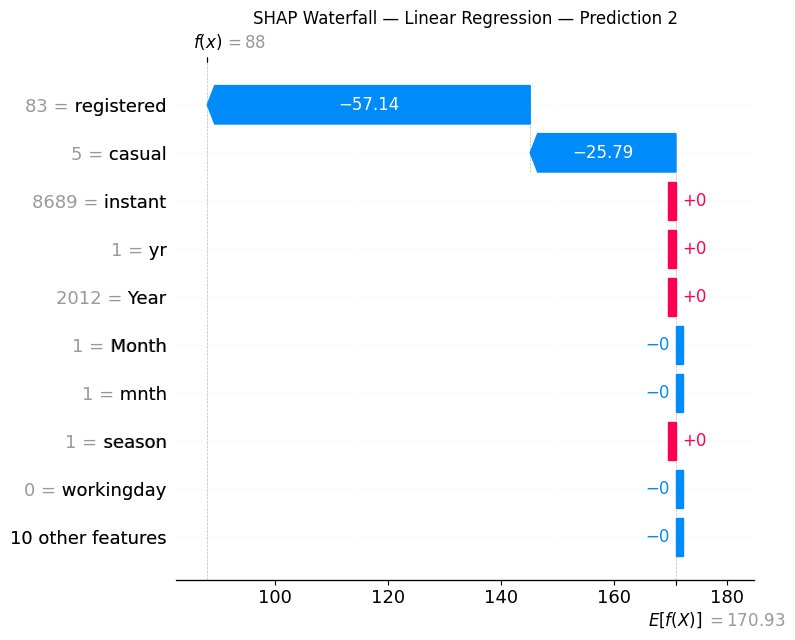

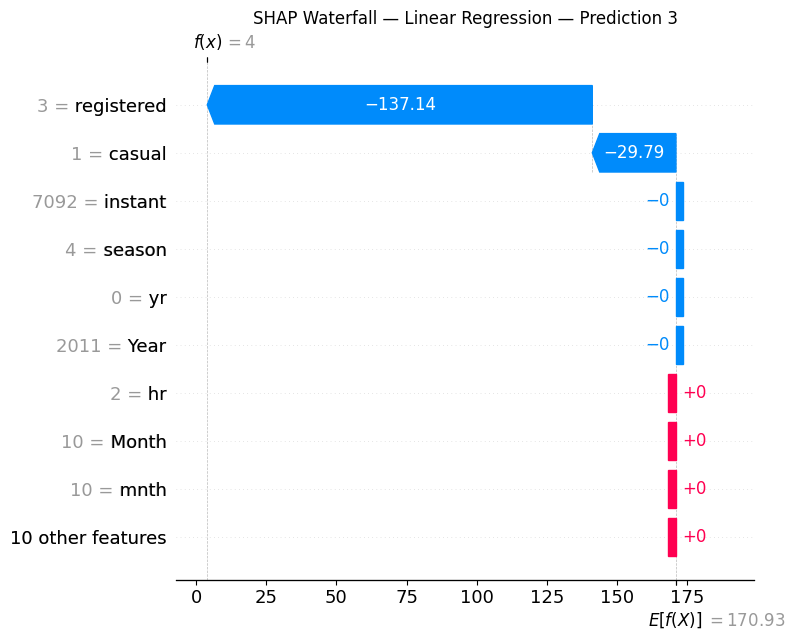

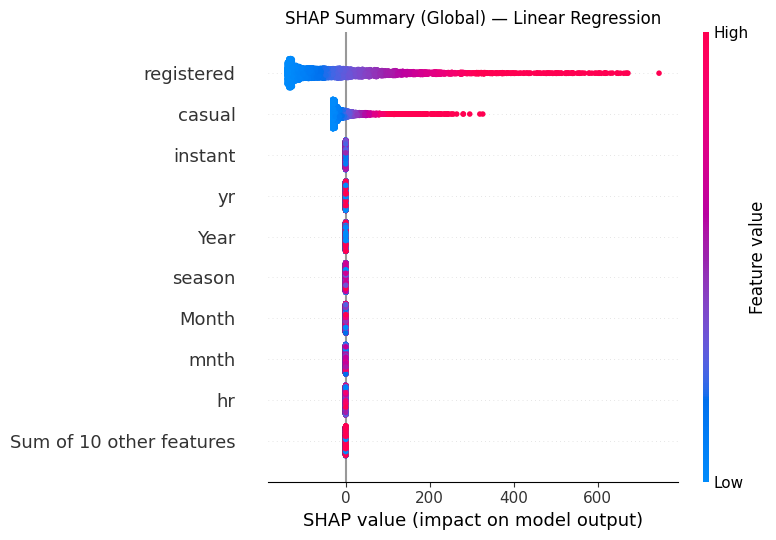

/home/xilas/DaT/python3venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


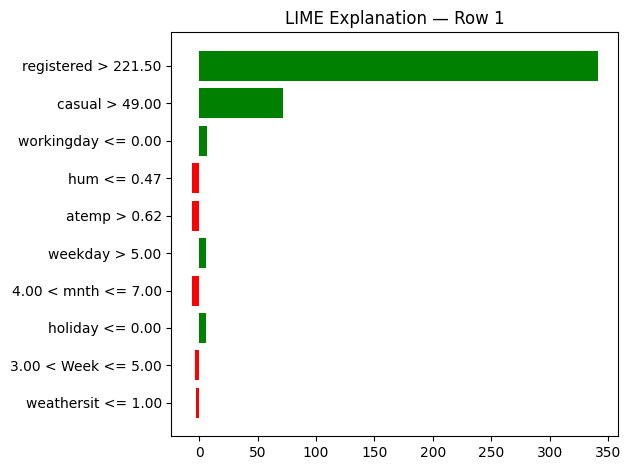

/home/xilas/DaT/python3venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


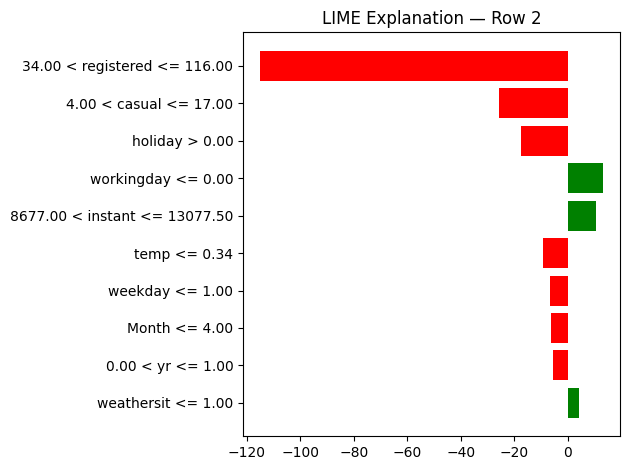

/home/xilas/DaT/python3venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


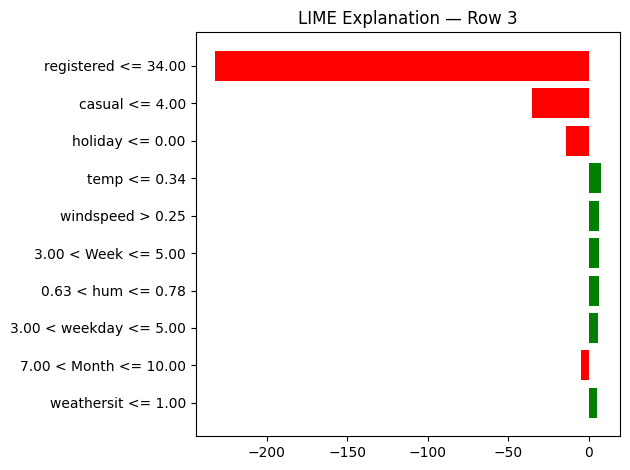

In [189]:

# ── SHAP: Random Forest ───────────────────────────────────────────────────
explainer_rf_shap = shap.Explainer(rf, X_train)
shap_values_rf = explainer_rf_shap(X_test, check_additivity=False)

# 3 local waterfall plots
for i in range(3):
    shap.plots.waterfall(shap_values_rf[i], show=False)
    plt.title(f"SHAP Waterfall — Random Forest — Prediction {i+1}")
    plt.tight_layout()
    plt.show()

# 1 global beeswarm plot
shap.plots.beeswarm(shap_values_rf, show=False)
plt.title("SHAP Summary (Global) — Random Forest")
plt.tight_layout()
plt.show()

# ── SHAP: Linear Regression ───────────────────────────────────────────────
# LinearExplainer does not support check_additivity — call without it
explainer_lr_shap = shap.Explainer(lin_reg, X_train)
shap_values_lr = explainer_lr_shap(X_test)

for i in range(3):
    shap.plots.waterfall(shap_values_lr[i], show=False)
    plt.title(f"SHAP Waterfall — Linear Regression — Prediction {i+1}")
    plt.tight_layout()
    plt.show()

shap.plots.beeswarm(shap_values_lr, show=False)
plt.title("SHAP Summary (Global) — Linear Regression")
plt.tight_layout()
plt.show()

# ── LIME: Random Forest (3 local explanations) ────────────────────────────
lime_explainer = lime_tabular.LimeTabularExplainer(
    X_train.values,
    feature_names=X_train.columns.tolist(),
    mode="regression"
)

for i in range(3):
    exp = lime_explainer.explain_instance(X_test.values[i], rf.predict, num_features=10)
    exp.as_pyplot_figure()
    plt.title(f"LIME Explanation — Row {i+1}")
    plt.tight_layout()
    plt.show()


---
# 12. Neural Networks and Deep Learning

**Exercise 2:** From "Exercises in neural network and deep learning II.ipynb"

*Note: This exercise requires accessing the specific notebook and dataset*

In [ ]:

import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import layers
from keras.datasets import imdb, reuters
from keras.utils import to_categorical

def multi_hot_encode(sequences, num_classes):
    results = np.zeros((len(sequences), num_classes))
    for i, sequence in enumerate(sequences):
        results[i][sequence] = 1.0
    return results

# ── IMDB data ──────────────────────────────────────────────────────────────
(imdb_train_data, imdb_train_labels), (imdb_test_data, imdb_test_labels) = \
    imdb.load_data(num_words=10000)

x_imdb_train = multi_hot_encode(imdb_train_data, 10000)
x_imdb_test  = multi_hot_encode(imdb_test_data,  10000)
y_imdb_train = imdb_train_labels.astype("float32")
y_imdb_test  = imdb_test_labels.astype("float32")

x_imdb_val           = x_imdb_train[:10000]
partial_x_imdb_train = x_imdb_train[10000:]
y_imdb_val           = y_imdb_train[:10000]
partial_y_imdb_train = y_imdb_train[10000:]

# ── Reuters data ───────────────────────────────────────────────────────────
(reuters_train_data, reuters_train_labels), (reuters_test_data, reuters_test_labels) = \
    reuters.load_data(num_words=10000)

x_reuters_train = multi_hot_encode(reuters_train_data, 10000)
x_reuters_test  = multi_hot_encode(reuters_test_data,  10000)
y_reuters_train = to_categorical(reuters_train_labels)
y_reuters_test  = to_categorical(reuters_test_labels)

x_reuters_val           = x_reuters_train[:1000]
partial_x_reuters_train = x_reuters_train[1000:]
y_reuters_val           = y_reuters_train[:1000]
partial_y_reuters_train = y_reuters_train[1000:]

print("IMDB   — train:", x_imdb_train.shape,    " test:", x_imdb_test.shape)
print("Reuters— train:", x_reuters_train.shape, " test:", x_reuters_test.shape)

# ── IMDB Experiments: layers, units, loss, activation ─────────────────────
def build_imdb_model(num_layers, units, activation, loss_fn):
    layer_list = [layers.Dense(units, activation=activation) for _ in range(num_layers)]
    layer_list.append(layers.Dense(1, activation="sigmoid"))
    model = keras.Sequential(layer_list)
    model.compile(optimizer="adam", loss=loss_fn, metrics=["accuracy"])
    return model

def run_imdb_experiment(label, num_layers=2, units=16, activation="relu",
                        loss_fn="binary_crossentropy", epochs=20):
    model = build_imdb_model(num_layers, units, activation, loss_fn)
    history = model.fit(
        partial_x_imdb_train, partial_y_imdb_train,
        epochs=epochs, batch_size=512,
        validation_data=(x_imdb_val, y_imdb_val),
        verbose=0,
    )
    test_loss, test_acc = model.evaluate(x_imdb_test, y_imdb_test, verbose=0)
    best_val_acc = max(history.history["val_accuracy"])
    print(f"[{label:50s}]  best_val_acc={best_val_acc:.4f}  test_acc={test_acc:.4f}")
    return history

imdb_histories = {}

print("=== Experiment 1: Number of hidden layers ===")
for n in [1, 2, 3]:
    imdb_histories[f"{n}_layers"] = run_imdb_experiment(
        f"{n} layer(s), 16 units, relu, bce", num_layers=n)

print("\n=== Experiment 2: Units per layer ===")
for u in [32, 64]:
    imdb_histories[f"{u}_units"] = run_imdb_experiment(
        f"2 layers, {u} units, relu, bce", units=u)

print("\n=== Experiment 3: MSE loss ===")
imdb_histories["mse"] = run_imdb_experiment(
    "2 layers, 16 units, relu, MSE", loss_fn="mean_squared_error")

print("\n=== Experiment 4: tanh activation ===")
imdb_histories["tanh"] = run_imdb_experiment(
    "2 layers, 16 units, tanh, bce", activation="tanh")

# ── Plot layer comparison ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for tag, label in [("1_layers", "1 hidden layer"), ("2_layers", "2 layers (baseline)"), ("3_layers", "3 hidden layers")]:
    val_acc  = imdb_histories[tag].history["val_accuracy"]
    val_loss = imdb_histories[tag].history["val_loss"]
    epochs_range = range(1, len(val_acc) + 1)
    axes[0].plot(epochs_range, val_acc,  label=label)
    axes[1].plot(epochs_range, val_loss, label=label)
axes[0].set(title="Val Accuracy — Layer count", xlabel="Epoch", ylabel="Accuracy")
axes[1].set(title="Val Loss — Layer count",     xlabel="Epoch", ylabel="Loss")
for ax in axes:
    ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Reuters Experiments ────────────────────────────────────────────────────
def build_reuters_model(num_intermediate_layers, units):
    layer_list = [layers.Dense(units, activation="relu") for _ in range(num_intermediate_layers)]
    layer_list.append(layers.Dense(46, activation="softmax"))
    model = keras.Sequential(layer_list)
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return model

def run_reuters_experiment(label, num_intermediate_layers=2, units=64, epochs=20):
    model = build_reuters_model(num_intermediate_layers, units)
    history = model.fit(
        partial_x_reuters_train, partial_y_reuters_train,
        epochs=epochs, batch_size=512,
        validation_data=(x_reuters_val, y_reuters_val),
        verbose=0,
    )
    test_loss, test_acc = model.evaluate(x_reuters_test, y_reuters_test, verbose=0)
    best_val_acc = max(history.history["val_accuracy"])
    print(f"[{label:50s}]  best_val_acc={best_val_acc:.4f}  test_acc={test_acc:.4f}")
    return history

reuters_histories = {}

print("\n=== Reuters Experiment 1: Units per layer ===")
for u in [32, 64, 128]:
    reuters_histories[f"{u}_units"] = run_reuters_experiment(f"2 layers, {u} units", units=u)

print("\n=== Reuters Experiment 2: Number of intermediate layers ===")
for n in [1, 2, 3]:
    reuters_histories[f"{n}_layers"] = run_reuters_experiment(f"{n} layer(s), 64 units", num_intermediate_layers=n)

# ── Plot Reuters layer comparison ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for tag, label in [("1_layers", "1 layer"), ("2_layers", "2 layers (baseline)"), ("3_layers", "3 layers")]:
    val_acc  = reuters_histories[tag].history["val_accuracy"]
    val_loss = reuters_histories[tag].history["val_loss"]
    epochs_range = range(1, len(val_acc) + 1)
    axes[0].plot(epochs_range, val_acc,  label=label)
    axes[1].plot(epochs_range, val_loss, label=label)
axes[0].set(title="Val Accuracy — Layer count (Reuters)", xlabel="Epoch", ylabel="Accuracy")
axes[1].set(title="Val Loss — Layer count (Reuters)",     xlabel="Epoch", ylabel="Loss")
for ax in axes:
    ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


I0000 00:00:1773502936.673388    3896 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1773502937.106755    3896 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773502944.540542    3896 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


/home/xilas/DaT/python3venv/lib/python3.12/site-packages/numpy/lib/_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 2s 1us/step
IMDB   — train: (25000, 10000)  test: (25000, 10000)
Reuters— train: (8982, 10000)  test: (2246, 10000)
=== Experiment 1: Number of hidden layers ===


E0000 00:00:1773502963.164452    3896 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
W0000 00:00:1773502966.994575    3896 cpu_allocator_impl.cc:82] Allocation of 600000000 exceeds 10% of free system memory.
W0000 00:00:1773502970.859342   27891 cpu_allocator_impl.cc:82] Allocation of 20480000 exceeds 10% of free system memory.
W0000 00:00:1773502970.859400   27895 cpu_allocator_impl.cc:82] Allocation of 20480000 exceeds 10% of free system memory.
W0000 00:00:1773502970.859430   27893 cpu_allocator_impl.cc:82] Allocation of 20480000 exceeds 10% of free system memory.
W0000 00:00:1773502970.859475   27889 cpu_allocator_impl.cc:82] Allocation of 20480000 exceeds 10% of free system memory.
W0000 00:00:1773502979.612248   27898 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 20482048 bytes after encountering the first element of size 20482048 bytes.This already causes the autotune ram budget to be exceeded. To sta

[1 layer(s), 16 units, relu, bce                   ]  best_val_acc=0.8906  test_acc=0.8609


W0000 00:00:1773503040.891200   28727 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 20482048 bytes after encountering the first element of size 20482048 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


[2 layer(s), 16 units, relu, bce                   ]  best_val_acc=0.8892  test_acc=0.8554
[3 layer(s), 16 units, relu, bce                   ]  best_val_acc=0.8873  test_acc=0.8579

=== Experiment 2: Units per layer ===


---
# 13. Generative AI

**Exercise:** Tasks from rag_task.ipynb

Tasks:
1. Create RAG pipeline
2. Try at least 3 types of chunking (paragraphs, sentences, punctuation)
3. Test different question formulations
4. Try at least one other similarity/distance function

*Note: This exercise requires accessing rag_task.ipynb*

---
# 14. Ethical Reflections on Data Science

**Exercise 1:** From "Exercises in Fairness in Machine Learning.ipynb"

*Note: This exercise requires accessing the specific notebook*

---
# 15. Logistic Regression

**Exercise 8:** Using the diabetes dataset

Tasks:
1. Load the diabetes dataset
2. Scatter plot (Outcome vs Glucose) + boxplot (Glucose by Outcome)
3. Single-feature logistic regression: Glucose → Outcome (train-test split 25%, random_state=42)
4. Train with `statsmodels.Logit` (remember to add constant)
5. Predict and calculate accuracy
6. Visualise the logistic regression curve with decision boundary
7. Multi-feature model (Glucose + BMI + Age) — does accuracy improve?


In [ ]:

# 1. Load diabetes dataset
diabetes_lr = pd.read_csv("Data/diabetes.csv")

# 2 & 3. Scatter plot and boxplot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(diabetes_lr["Glucose"], diabetes_lr["Outcome"], alpha=0.4)
axes[0].set_xlabel("Glucose")
axes[0].set_ylabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
axes[0].set_title("Outcome vs Glucose")
sns.boxplot(x="Outcome", y="Glucose", data=diabetes_lr, ax=axes[1])
axes[1].set_xlabel("Outcome")
axes[1].set_title("Glucose Distribution by Diabetes Outcome")
plt.tight_layout()
plt.show()

# 4-6. Single-feature logistic regression (Glucose → Outcome)
X_gluc_lr = diabetes_lr[["Glucose"]]
y_diab_lr = diabetes_lr["Outcome"]
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_gluc_lr, y_diab_lr, test_size=0.25, random_state=42
)
X_train_sm_lr = sm.add_constant(X_train_lr)
X_test_sm_lr  = sm.add_constant(X_test_lr)

logit_model = sm.Logit(y_train_lr, X_train_sm_lr).fit()
print(logit_model.summary())

# 7-8. Predictions and accuracy
y_prob_lr = logit_model.predict(X_test_sm_lr)
y_pred_lr = (y_prob_lr >= 0.5).astype(int)
print(f"\nAccuracy (single feature — Glucose): {accuracy_score(y_test_lr, y_pred_lr):.4f}")

# 9. Logistic regression curve visualisation
glucose_range_lr = np.linspace(diabetes_lr["Glucose"].min(), diabetes_lr["Glucose"].max(), 300)
X_plot_lr = sm.add_constant(pd.DataFrame({"Glucose": glucose_range_lr}))
y_plot_lr = logit_model.predict(X_plot_lr)

plt.figure(figsize=(10, 6))
plt.scatter(diabetes_lr["Glucose"], diabetes_lr["Outcome"], alpha=0.3, label="Observations")
plt.plot(glucose_range_lr, y_plot_lr, color="red", linewidth=2, label="Logistic Curve")
plt.axhline(0.5, color="gray", linestyle="--", label="Decision boundary (p=0.5)")
plt.xlabel("Glucose")
plt.ylabel("P(Diabetes)")
plt.title("Logistic Regression: Glucose → P(Diabetes)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 10. Multi-feature model: Glucose + BMI + Age
X_multi_lr = diabetes_lr[["Glucose", "BMI", "Age"]]
X_train_m_lr, X_test_m_lr, y_train_m_lr, y_test_m_lr = train_test_split(
    X_multi_lr, y_diab_lr, test_size=0.25, random_state=42
)
logit_multi = sm.Logit(y_train_m_lr, sm.add_constant(X_train_m_lr)).fit()
y_pred_multi = (logit_multi.predict(sm.add_constant(X_test_m_lr)) >= 0.5).astype(int)

print(f"\nAccuracy (multi-feature: Glucose + BMI + Age): {accuracy_score(y_test_m_lr, y_pred_multi):.4f}")
print(f"Accuracy (single feature: Glucose):            {accuracy_score(y_test_lr, y_pred_lr):.4f}")
print("\nAdding BMI and Age improves model accuracy as they both contribute additional information.")


---
# 16. Classification Model Evaluation (ROC & AUC)

**Exercise 11:** Using the diabetes dataset with KNN classifiers

Tasks:
1. Load diabetes dataset — features (drop Age & Outcome) → X, Outcome → y
2. Train-test split (25%, random_state=42) and scale
3. Train KNN with K=5 and K=10
4. Confusion matrices (array + `ConfusionMatrixDisplay`)
5. Calculate accuracy, precision, recall, F1
6. Normalised confusion matrix (percentages)
7. ROC curves and AUC for both models
8. Which model performs better and why?


In [ ]:

from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, roc_auc_score

# 1-4. Load diabetes, select features, split
diabetes_eval = pd.read_csv("Data/diabetes.csv")
X_ev = diabetes_eval.drop(columns=["Age", "Outcome"])
y_ev = diabetes_eval["Outcome"]

X_tr_ev, X_te_ev, y_tr_ev, y_te_ev = train_test_split(X_ev, y_ev, test_size=0.25, random_state=42)

sc_ev = StandardScaler()
X_tr_ev_sc = sc_ev.fit_transform(X_tr_ev)
X_te_ev_sc = sc_ev.transform(X_te_ev)

knn5_ev  = KNeighborsClassifier(n_neighbors=5).fit(X_tr_ev_sc, y_tr_ev)
knn10_ev = KNeighborsClassifier(n_neighbors=10).fit(X_tr_ev_sc, y_tr_ev)

y_pred_ev5  = knn5_ev.predict(X_te_ev_sc)
y_pred_ev10 = knn10_ev.predict(X_te_ev_sc)

# Confusion matrices
cm_ev5  = confusion_matrix(y_te_ev, y_pred_ev5)
cm_ev10 = confusion_matrix(y_te_ev, y_pred_ev10)
print("Confusion Matrix K=5:\n",  cm_ev5)
print("\nConfusion Matrix K=10:\n", cm_ev10)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(cm_ev5,  display_labels=["No Diabetes", "Diabetes"]).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix K=5")
ConfusionMatrixDisplay(cm_ev10, display_labels=["No Diabetes", "Diabetes"]).plot(ax=axes[1], colorbar=False)
axes[1].set_title("Confusion Matrix K=10")
plt.tight_layout()
plt.show()

# Metrics comparison
metrics_ev = pd.DataFrame({
    "K=5":  [accuracy_score(y_te_ev, y_pred_ev5),  precision_score(y_te_ev, y_pred_ev5),
             recall_score(y_te_ev, y_pred_ev5),    f1_score(y_te_ev, y_pred_ev5)],
    "K=10": [accuracy_score(y_te_ev, y_pred_ev10), precision_score(y_te_ev, y_pred_ev10),
             recall_score(y_te_ev, y_pred_ev10),   f1_score(y_te_ev, y_pred_ev10)],
}, index=["Accuracy", "Precision", "Recall", "F1-Score"])
print("\nMetrics Comparison:")
print(metrics_ev.to_string())

# Normalised confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, cm_n, title in zip(axes, [cm_ev5, cm_ev10], ["K=5 (normalised)", "K=10 (normalised)"]):
    cm_norm = cm_n.astype(float) / cm_n.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt=".1%", cmap="Blues", ax=ax,
                xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"])
    ax.set_title(title)
plt.tight_layout()
plt.show()

# ROC curves & AUC
y_prob_ev5  = knn5_ev.predict_proba(X_te_ev_sc)[:, 1]
y_prob_ev10 = knn10_ev.predict_proba(X_te_ev_sc)[:, 1]
auc5_ev  = roc_auc_score(y_te_ev, y_prob_ev5)
auc10_ev = roc_auc_score(y_te_ev, y_prob_ev10)

fpr5_ev,  tpr5_ev,  _ = roc_curve(y_te_ev, y_prob_ev5)
fpr10_ev, tpr10_ev, _ = roc_curve(y_te_ev, y_prob_ev10)

plt.figure(figsize=(8, 6))
plt.plot(fpr5_ev,  tpr5_ev,  label=f"K=5  (AUC={auc5_ev:.4f})")
plt.plot(fpr10_ev, tpr10_ev, label=f"K=10 (AUC={auc10_ev:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — KNN Classifiers (K=5 vs K=10)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

better_ev = "K=5" if auc5_ev > auc10_ev else "K=10"
print(f"\nBetter model: {better_ev} (AUC={max(auc5_ev, auc10_ev):.4f})")
print("Higher AUC means better ability to distinguish diabetic from non-diabetic patients.")


---
# 17. Decision Trees and Ensemble Models

**Exercise 12:** Using the diabetes dataset

Tasks:
1. Load dataset, select Glucose, BloodPressure, Insulin, BMI as features, Outcome as target
2. Train-test split (20%, random_state=8532)
3. Train a basic Decision Tree — confusion matrices for train and test
4. Calculate accuracy, precision, recall, F1 for both sets
5. Visualize the tree structure
6. Train Random Forest, AdaBoost, and XGBoost classifiers
7. Compare all four models
8. Tune max_depth to reduce Decision Tree overfitting


In [ ]:

from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from xgboost import XGBClassifier

# 1-3. Load data and split
diabetes_dt = pd.read_csv("Data/diabetes.csv")
X_dt = diabetes_dt[["Glucose", "BloodPressure", "Insulin", "BMI"]]
y_dt = diabetes_dt["Outcome"]
X_tr_dt, X_te_dt, y_tr_dt, y_te_dt = train_test_split(X_dt, y_dt, test_size=0.2, random_state=8532)

def report(name, y_true, y_pred):
    print(f"\n{name}:")
    print(f"  Accuracy={accuracy_score(y_true, y_pred):.4f}  "
          f"Precision={precision_score(y_true, y_pred):.4f}  "
          f"Recall={recall_score(y_true, y_pred):.4f}  "
          f"F1={f1_score(y_true, y_pred):.4f}")

# 4-7. Basic Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_tr_dt, y_tr_dt)
y_tr_pred_dt = dt.predict(X_tr_dt)
y_te_pred_dt = dt.predict(X_te_dt)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_tr_dt, y_tr_pred_dt)).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Decision Tree — Training")
ConfusionMatrixDisplay(confusion_matrix(y_te_dt, y_te_pred_dt)).plot(ax=axes[1], colorbar=False)
axes[1].set_title("Decision Tree — Test")
plt.tight_layout()
plt.show()

report("Decision Tree (Train)", y_tr_dt, y_tr_pred_dt)
report("Decision Tree (Test)",  y_te_dt, y_te_pred_dt)

print("\nDecision Tree Structure (max depth 3):")
print(export_text(dt, feature_names=list(X_dt.columns), max_depth=3))

# 9. Random Forest
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_tr_dt, y_tr_dt)
report("Random Forest (Test)", y_te_dt, rf_clf.predict(X_te_dt))

# 10. AdaBoost
ada = AdaBoostClassifier(n_estimators=100, random_state=42)
ada.fit(X_tr_dt, y_tr_dt)
report("AdaBoost (Test)", y_te_dt, ada.predict(X_te_dt))

# 11. XGBoost
xgb_clf = XGBClassifier(n_estimators=100, random_state=42, eval_metric="logloss", verbosity=0)
xgb_clf.fit(X_tr_dt, y_tr_dt)
report("XGBoost (Test)", y_te_dt, xgb_clf.predict(X_te_dt))

# 12. Model comparison summary
print("\n" + "="*60)
print("Model comparison summary (Test set):")
models_compare = {
    "Decision Tree": dt, "Random Forest": rf_clf, "AdaBoost": ada, "XGBoost": xgb_clf
}
rows = []
for name, mdl in models_compare.items():
    yp = mdl.predict(X_te_dt)
    rows.append({"Model": name, "Accuracy": accuracy_score(y_te_dt, yp),
                 "F1": f1_score(y_te_dt, yp),
                 "Precision": precision_score(y_te_dt, yp),
                 "Recall": recall_score(y_te_dt, yp)})
print(pd.DataFrame(rows).set_index("Model").to_string())

# 13. Reduce DT overfitting with max_depth tuning
print("\nDecision Tree — varying max_depth:")
for d in [2, 3, 4, 5, None]:
    dt_d = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt_d.fit(X_tr_dt, y_tr_dt)
    tr_acc = accuracy_score(y_tr_dt, dt_d.predict(X_tr_dt))
    te_acc = accuracy_score(y_te_dt, dt_d.predict(X_te_dt))
    print(f"  max_depth={str(d):4s}  train={tr_acc:.4f}  test={te_acc:.4f}")


---
# 18. Hyperparameter Tuning and Cross-Validation

**Exercise 17:** Using the diabetes dataset

Tasks:
1. Train 50 KNN models (K=5) with different random splits — histogram of accuracies
2. Find best K (2–30) per split — histogram of best K values
3. Grid Search CV to find best K for KNN
4. Randomised Search CV for hyperparameter tuning
5. `cross_val_score` with 5-fold CV
6. Grid Search to tune Random Forest hyperparameters
7. Compare all methods — which gives the most reliable results?


In [ ]:

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score
from scipy.stats import randint

# 1-2. Load diabetes, select features
diabetes_hp = pd.read_csv("Data/diabetes.csv")
X_hp = diabetes_hp.drop(columns=["Age", "Outcome"])
y_hp = diabetes_hp["Outcome"]

# ── Task 3-4: 50 random splits with KNN K=5 ──────────────────────────────
rng = np.random.default_rng(0)
seeds = rng.integers(0, 10_000, size=50)
accs_50 = []
for seed in seeds:
    X_tr, X_te, y_tr, y_te = train_test_split(X_hp, y_hp, test_size=0.25, random_state=int(seed))
    sc = StandardScaler()
    knn_h = KNeighborsClassifier(n_neighbors=5)
    knn_h.fit(sc.fit_transform(X_tr), y_tr)
    accs_50.append(accuracy_score(y_te, knn_h.predict(sc.transform(X_te))))

plt.figure(figsize=(10, 4))
plt.hist(accs_50, bins=15, edgecolor="black")
plt.title("Distribution of Test Accuracies (50 random splits, K=5)")
plt.xlabel("Accuracy")
plt.ylabel("Count")
plt.show()
print(f"Mean accuracy: {np.mean(accs_50):.4f}  Std: {np.std(accs_50):.4f}")

# ── Task 5-6: Best K (2–30) per split ─────────────────────────────────────
best_ks = []
for seed in seeds:
    X_tr, X_te, y_tr, y_te = train_test_split(X_hp, y_hp, test_size=0.25, random_state=int(seed))
    sc = StandardScaler()
    X_tr_sc = sc.fit_transform(X_tr)
    X_te_sc  = sc.transform(X_te)
    best_k, best_acc = 2, 0
    for k in range(2, 31):
        knn_h = KNeighborsClassifier(n_neighbors=k)
        knn_h.fit(X_tr_sc, y_tr)
        acc = accuracy_score(y_te, knn_h.predict(X_te_sc))
        if acc > best_acc:
            best_acc, best_k = acc, k
    best_ks.append(best_k)

plt.figure(figsize=(10, 4))
plt.hist(best_ks, bins=range(2, 32), edgecolor="black", align="left")
plt.title("Distribution of Best K Values (50 random splits)")
plt.xlabel("Best K")
plt.ylabel("Count")
plt.show()
print(f"Most common best K: {pd.Series(best_ks).mode()[0]}")

# ── Task 7: Grid Search CV ────────────────────────────────────────────────
X_hp_sc = StandardScaler().fit_transform(X_hp)
param_grid_knn = {"n_neighbors": range(2, 31)}
gs_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5, scoring="accuracy")
gs_knn.fit(X_hp_sc, y_hp)
print(f"\nGrid Search best K={gs_knn.best_params_['n_neighbors']}, "
      f"CV accuracy={gs_knn.best_score_:.4f}")

# ── Task 8: Randomised Search CV ─────────────────────────────────────────
rs_knn = RandomizedSearchCV(
    KNeighborsClassifier(),
    {"n_neighbors": randint(2, 31)},
    n_iter=20, cv=5, scoring="accuracy", random_state=42
)
rs_knn.fit(X_hp_sc, y_hp)
print(f"Random Search best K={rs_knn.best_params_['n_neighbors']}, "
      f"CV accuracy={rs_knn.best_score_:.4f}")

# ── Task 9: cross_val_score ────────────────────────────────────────────────
cv_scores = cross_val_score(
    KNeighborsClassifier(n_neighbors=gs_knn.best_params_["n_neighbors"]),
    X_hp_sc, y_hp, cv=5, scoring="accuracy"
)
print(f"\n5-fold CV scores: {np.round(cv_scores, 4)}")
print(f"Mean={cv_scores.mean():.4f}  Std={cv_scores.std():.4f}")

# ── Task 11: Grid Search for Random Forest ─────────────────────────────────
rf_param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth":    [None, 5, 10],
    "min_samples_split": [2, 5],
}
rf_gs = GridSearchCV(
    RandomForestRegressor(random_state=42), rf_param_grid, cv=5, scoring="neg_mean_squared_error"
)
rf_gs.fit(X_hp_sc, y_hp)
print(f"\nRandom Forest Grid Search best params: {rf_gs.best_params_}")

# ── Conclusions ────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("Reliability comparison:")
print("  • Single random split   → highly variable; depends on which samples land in test set.")
print("  • 50 random splits      → better distribution view; still no train/val separation.")
print("  • GridSearchCV (5-fold) → most reliable; uses all data for training AND validation.")
print("  • RandomSearchCV        → nearly as reliable as Grid Search, faster for large spaces.")
print("  → Grid Search with cross-validation is the gold standard for hyperparameter tuning.")
